# Temperature-Based Crime-Type Forecasting

This experiment reads the street-crime data, groups it by month/LSOA/crime type, keeps the target LSOA, scrapes that LSOA's monthly average temperature, then compares SARIMA, XGBoost, and Prophet for each crime type.


In [1]:
from pathlib import Path
import calendar
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from IPython.display import display
from tqdm.auto import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

RANDOM_STATE = 42


/Users/anas/PythonProjects/CBL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_CANDIDATES = [
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path("/kaggle/input/datasets/anasnofal/uk-police-crime-dataset-mar-2023-feb-2025"),
    Path("/kaggle/input/uk-police-crime-dataset-mar-2023-feb-2025"),
]

DATA_DIR = next(
    (path for path in DATA_CANDIDATES if (path / "all_street.csv").exists()), None
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find all_street.csv. Check DATA_CANDIDATES or your data folder."
    )

REPO_ROOT = DATA_DIR.parent if DATA_DIR.name == "data" else Path.cwd()
NOTEBOOK_DIR = REPO_ROOT / "notebooks" if (REPO_ROOT / "notebooks").exists() else Path.cwd()
OUTPUT_DIR = NOTEBOOK_DIR / "forecast_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "street": DATA_DIR / "all_street.csv",
    "outcomes": DATA_DIR / "all_outcomes.csv",
    "stop_search": DATA_DIR / "all_stop_and_search.csv",
}

print(f"Using data directory: {DATA_DIR}")
print(f"Using output directory: {OUTPUT_DIR}")
for name, path in paths.items():
    print(f"{name:12s}: {path}")


Using data directory: /Users/anas/PythonProjects/CBL/data
Using output directory: /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs
street      : /Users/anas/PythonProjects/CBL/data/all_street.csv
outcomes    : /Users/anas/PythonProjects/CBL/data/all_outcomes.csv
stop_search : /Users/anas/PythonProjects/CBL/data/all_stop_and_search.csv


## Configuration



In [ ]:
TARGET_LSOA = "E01035716" #"E01032739" E01035716	Westminster 013G
TARGET_LSOA_NAME = "Westminster 013G"# "City of London 001F"

CRIME_TYPE_CACHE = OUTPUT_DIR / f"{TARGET_LSOA}_monthly_crime_type_counts.csv"
TEMPERATURE_CACHE = OUTPUT_DIR / f"{TARGET_LSOA}_monthly_temperature.csv"
MODEL_COMPARISON_CACHE = OUTPUT_DIR / f"{TARGET_LSOA}_crime_type_model_comparison.csv"
CV_FORECAST_CACHE = OUTPUT_DIR / f"{TARGET_LSOA}_crime_type_forecasts.csv"
FUTURE_FORECAST_CACHE = OUTPUT_DIR / f"{TARGET_LSOA}_crime_type_future_forecasts.csv"

OPEN_METEO_URL = "https://archive-api.open-meteo.com/v1/archive"
OPEN_METEO_BATCH_SIZE = 25
OPEN_METEO_SLEEP_SECONDS = 0.15

# Turn this on when you only want to test the weather API cell quickly without web scraping.
WEATHER_TEST_MODE = False
WEATHER_TEST_MONTHS = 3
WEATHER_TEST_CACHE = OUTPUT_DIR / f"{TARGET_LSOA}_monthly_temperature_test.csv"

ROLLING_TRAIN_MONTHS = 24
ROLLING_TEST_MONTHS = 3
ROLLING_STEP_MONTHS = 3
FINAL_FORECAST_HORIZON = 6

SARIMA_ORDERS = [
    (0, 0, 1),
    (1, 0, 0),
    (1, 0, 1),
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
]
SARIMA_SEASONAL_ORDERS = [
    (0, 0, 0, 12),
    (1, 0, 0, 12),
    (0, 1, 1, 12),
]

XGB_LAGS = [1, 2, 3, 6, 12]
XGB_FEATURE_COLUMNS = [
    "month_num",
    "month_sin",
    "month_cos",
    "avg_temperature_c",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_3_mean",
    "rolling_6_mean",
    "rolling_12_mean",
]

## Shared Helpers


In [4]:
def normalize_month(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce").dt.to_period("M").dt.to_timestamp()


def smape(actual: np.ndarray, predicted: np.ndarray) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    denominator = np.abs(actual) + np.abs(predicted)
    values = np.divide(
        2.0 * np.abs(predicted - actual),
        denominator,
        out=np.zeros_like(actual, dtype=float),
        where=denominator != 0,
    )
    return float(np.mean(values) * 100)


def regression_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict[str, float]:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = predicted - actual
    return {
        "mae": float(np.mean(np.abs(errors))),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "smape": smape(actual, predicted),
    }


def month_features(month: pd.Timestamp) -> dict[str, float]:
    month_num = int(pd.Timestamp(month).month)
    return {
        "month_num": month_num,
        "month_sin": float(np.sin(2 * np.pi * month_num / 12)),
        "month_cos": float(np.cos(2 * np.pi * month_num / 12)),
    }



## Aggregate Street Crime by LSOA, Month, and Crime Type

This cell reads the street data once, groups it by month/LSOA/crime type, and then keeps only `TARGET_LSOA` for the forecasting workflow.


In [5]:
if CRIME_TYPE_CACHE.exists():
    monthly_counts = pd.read_csv(CRIME_TYPE_CACHE, parse_dates=["Month"])
    print(f"Loaded cached target crime-type counts: {CRIME_TYPE_CACHE}")
else:
    usecols = ["Month", "LSOA code", "LSOA name", "Crime type", "Longitude", "Latitude"]
    street = pd.read_csv(
        paths["street"],
        usecols=usecols,
        dtype=str,
        encoding="utf-8-sig",
        on_bad_lines="warn",
    )
    street = street.dropna(subset=["Month", "LSOA code", "Crime type"])
    street["Month"] = normalize_month(street["Month"])
    street["Latitude"] = pd.to_numeric(street["Latitude"], errors="coerce")
    street["Longitude"] = pd.to_numeric(street["Longitude"], errors="coerce")
    street = street.dropna(subset=["Month"])

    grouped_counts = (
        street.groupby(["Month", "LSOA code", "LSOA name", "Crime type"], observed=True)
        .agg(
            crime_count=("Crime type", "size"),
            latitude=("Latitude", "mean"),
            longitude=("Longitude", "mean"),
        )
        .reset_index()
    )

    monthly_counts = grouped_counts[grouped_counts["LSOA code"].eq(TARGET_LSOA)].copy()
    monthly_counts = monthly_counts[
        ["Month", "LSOA code", "LSOA name", "Crime type", "crime_count", "latitude", "longitude"]
    ].sort_values(["Crime type", "Month"])
    monthly_counts.to_csv(CRIME_TYPE_CACHE, index=False)
    print(f"Wrote target crime-type counts cache: {CRIME_TYPE_CACHE}")

summary = {
    "rows": len(monthly_counts),
    "months": monthly_counts["Month"].nunique(),
    "month_min": monthly_counts["Month"].min(),
    "month_max": monthly_counts["Month"].max(),
    "lsoas": monthly_counts["LSOA code"].nunique(),
    "crime_types": monthly_counts["Crime type"].nunique(),
}
display(pd.DataFrame([summary]))

monthly_counts.head()


Loaded cached target crime-type counts: /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_monthly_crime_type_counts.csv


,rows,months,month_min,month_max,lsoas,crime_types
0,491,36,2023-03-01,2026-02-01,1,14


,Month,LSOA code,LSOA name,Crime type,crime_count,latitude,longitude
0,2023-06-01,E01035716,Westminster 013G,Anti-social behaviour,61,51.51,-0.14
1,2023-07-01,E01035716,Westminster 013G,Anti-social behaviour,70,51.51,-0.14
2,2023-08-01,E01035716,Westminster 013G,Anti-social behaviour,72,51.51,-0.14
3,2023-09-01,E01035716,Westminster 013G,Anti-social behaviour,68,51.51,-0.14
4,2023-10-01,E01035716,Westminster 013G,Anti-social behaviour,85,51.51,-0.14


## LSOA Overview 


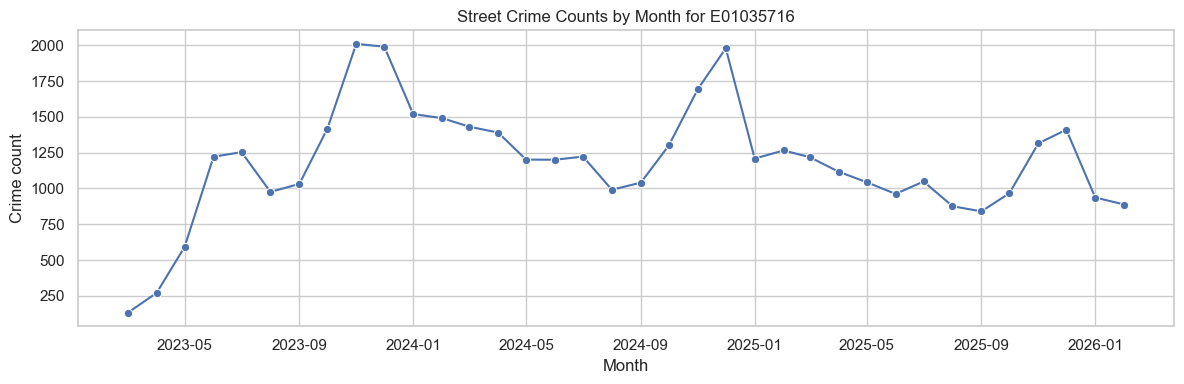

In [6]:
target_crime_monthly = (
    monthly_counts.groupby("Month", as_index=False)["crime_count"].sum().sort_values("Month")
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=target_crime_monthly, x="Month", y="crime_count", marker="o")
plt.title(f"Street Crime Counts by Month for {TARGET_LSOA}")
plt.xlabel("Month")
plt.ylabel("Crime count")
plt.tight_layout()
plt.show()


## Scrape and Cache Monthly Average Temperature

Temperature is fetched from the Open-Meteo historical archive using the target LSOA's representative coordinates calculated from its street-crime records. The cache is resumable for the target LSOA.


In [7]:
def requested_date_window(
    months: pd.Series,
    test_mode: bool = WEATHER_TEST_MODE,
    test_months: int = WEATHER_TEST_MONTHS,
) -> tuple[str, str, pd.DatetimeIndex]:
    month_index = pd.date_range(months.min(), months.max(), freq="MS")
    if test_mode:
        month_index = month_index[:test_months]

    start_date = month_index.min().strftime("%Y-%m-%d")
    last_month = month_index.max()
    end_day = calendar.monthrange(int(last_month.year), int(last_month.month))[1]
    end_date = last_month.replace(day=end_day).strftime("%Y-%m-%d")
    return start_date, end_date, month_index


def fetch_open_meteo_batch(batch: pd.DataFrame, start_date: str, end_date: str) -> pd.DataFrame:
    params = {
        "latitude": ",".join(batch["latitude"].map(lambda value: f"{value:.6f}")),
        "longitude": ",".join(batch["longitude"].map(lambda value: f"{value:.6f}")),
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/London",
        "temperature_unit": "celsius",
    }
    response = requests.get(OPEN_METEO_URL, params=params, timeout=90)
    if not response.ok:
        raise RuntimeError(f"Open-Meteo request failed: {response.status_code} {response.text[:500]}")

    payload = response.json()
    payloads = payload if isinstance(payload, list) else [payload]
    if len(payloads) != len(batch):
        raise RuntimeError(f"Expected {len(batch)} Open-Meteo payloads, received {len(payloads)}")

    rows: list[dict] = []
    for (_, lsoa), item in zip(batch.iterrows(), payloads):
        daily = item.get("daily", {})
        dates = daily.get("time", [])
        temps = daily.get("temperature_2m_mean", [])
        if not dates or not temps:
            continue

        daily_frame = pd.DataFrame(
            {
                "date": pd.to_datetime(dates, errors="coerce"),
                "temperature_2m_mean": pd.to_numeric(pd.Series(temps), errors="coerce"),
            }
        ).dropna(subset=["date", "temperature_2m_mean"])
        if daily_frame.empty:
            continue

        daily_frame["Month"] = daily_frame["date"].dt.to_period("M").dt.to_timestamp()
        monthly = daily_frame.groupby("Month", as_index=False)["temperature_2m_mean"].mean()
        for row in monthly.itertuples(index=False):
            rows.append(
                {
                    "Month": row.Month,
                    "LSOA code": lsoa["LSOA code"],
                    "avg_temperature_c": float(row.temperature_2m_mean),
                }
            )
    return pd.DataFrame(rows)


def load_or_fetch_monthly_temperature(
    lsoa_locations: pd.DataFrame,
    months: pd.Series,
    cache_path: Path,
    batch_size: int = OPEN_METEO_BATCH_SIZE,
    sleep_seconds: float = OPEN_METEO_SLEEP_SECONDS,
) -> pd.DataFrame:
    start_date, end_date, month_index = requested_date_window(months)
    expected_month_count = len(month_index)

    if cache_path.exists():
        existing = pd.read_csv(cache_path, parse_dates=["Month"])
        print(f"Loaded cached temperature data: {cache_path}")
    else:
        existing = pd.DataFrame(columns=["Month", "LSOA code", "avg_temperature_c"])

    location_frame = (
        lsoa_locations.dropna(subset=["latitude", "longitude"])
        .drop_duplicates("LSOA code")
        .sort_values("LSOA code")
        .reset_index(drop=True)
    )
    coverage = (
        existing[existing["Month"].isin(month_index)]
        .groupby("LSOA code")["Month"]
        .nunique()
    )
    missing_codes = location_frame[
        ~location_frame["LSOA code"].isin(coverage[coverage >= expected_month_count].index)
    ]

    if missing_codes.empty:
        return existing.sort_values(["LSOA code", "Month"]).reset_index(drop=True)

    print(
        f"Fetching temperature for {len(missing_codes):,} LSOA location(s) "
        f"from {start_date} to {end_date}."
    )
    fetched_chunks: list[pd.DataFrame] = []
    for start in tqdm(range(0, len(missing_codes), batch_size), desc="Fetching Open-Meteo batches"):
        batch = missing_codes.iloc[start : start + batch_size]
        fetched_chunks.append(fetch_open_meteo_batch(batch, start_date, end_date))

        if len(fetched_chunks) >= 20:
            existing = pd.concat([existing, *fetched_chunks], ignore_index=True)
            existing = existing.drop_duplicates(["Month", "LSOA code"], keep="last")
            existing.to_csv(cache_path, index=False)
            fetched_chunks = []

        if sleep_seconds:
            time.sleep(sleep_seconds)

    if fetched_chunks:
        existing = pd.concat([existing, *fetched_chunks], ignore_index=True)

    existing = existing.drop_duplicates(["Month", "LSOA code"], keep="last")
    existing = existing.sort_values(["LSOA code", "Month"]).reset_index(drop=True)
    existing.to_csv(cache_path, index=False)
    print(f"Wrote temperature cache: {cache_path}")
    return existing


target_lsoa_location = (
    monthly_counts[["LSOA code", "LSOA name", "latitude", "longitude"]]
    .query("`LSOA code` == @TARGET_LSOA")
    .drop_duplicates("LSOA code")
    .sort_values("LSOA code")
    .reset_index(drop=True)
)

temperature_cache_path = WEATHER_TEST_CACHE if WEATHER_TEST_MODE else TEMPERATURE_CACHE

monthly_temperature = load_or_fetch_monthly_temperature(
    target_lsoa_location,
    monthly_counts["Month"],
    temperature_cache_path,
)
monthly_temperature.head()


Loaded cached temperature data: /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_monthly_temperature.csv


,Month,LSOA code,avg_temperature_c
0,2023-03-01,E01035716,7.42
1,2023-04-01,E01035716,8.77
2,2023-05-01,E01035716,12.64
3,2023-06-01,E01035716,18.07
4,2023-07-01,E01035716,17.41


## Prepare Selected LSOA Crime-Type Series


Target LSOA: E01035716 / Westminster 013G


,Crime type,crime_count
11,Theft from the person,16651
6,Other theft,10064
10,Shoplifting,4813
13,Violence and sexual offences,2741
0,Anti-social behaviour,2278
9,Robbery,1649
12,Vehicle crime,1441
8,Public order,766
2,Burglary,680
4,Drugs,638


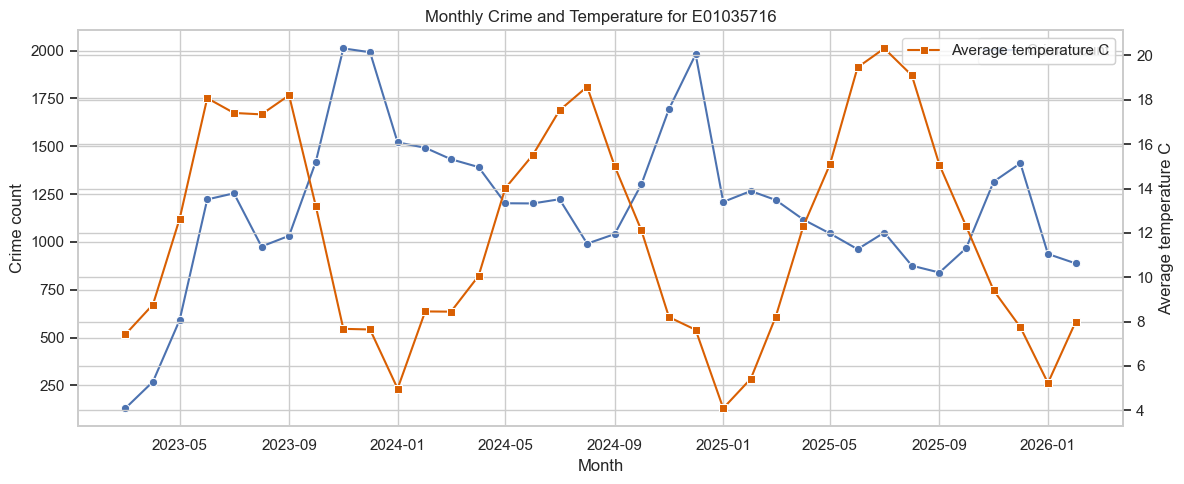

Temperature and crime-count relationship by crime type


,Crime type,months,total_crime,pearson_temp_vs_crime,spearman_temp_vs_crime
0,Theft from the person,36,16651,-0.47,-0.51
1,Other theft,36,10064,0.02,0.03
2,Shoplifting,36,4813,-0.08,-0.22
3,Violence and sexual offences,36,2741,0.13,0.07
4,Anti-social behaviour,36,2278,0.26,0.25
5,Robbery,36,1649,0.00,-0.06
6,Vehicle crime,36,1441,-0.06,-0.03
7,Public order,36,766,0.08,0.05
8,Burglary,36,680,-0.15,-0.15
9,Drugs,36,638,0.02,0.02


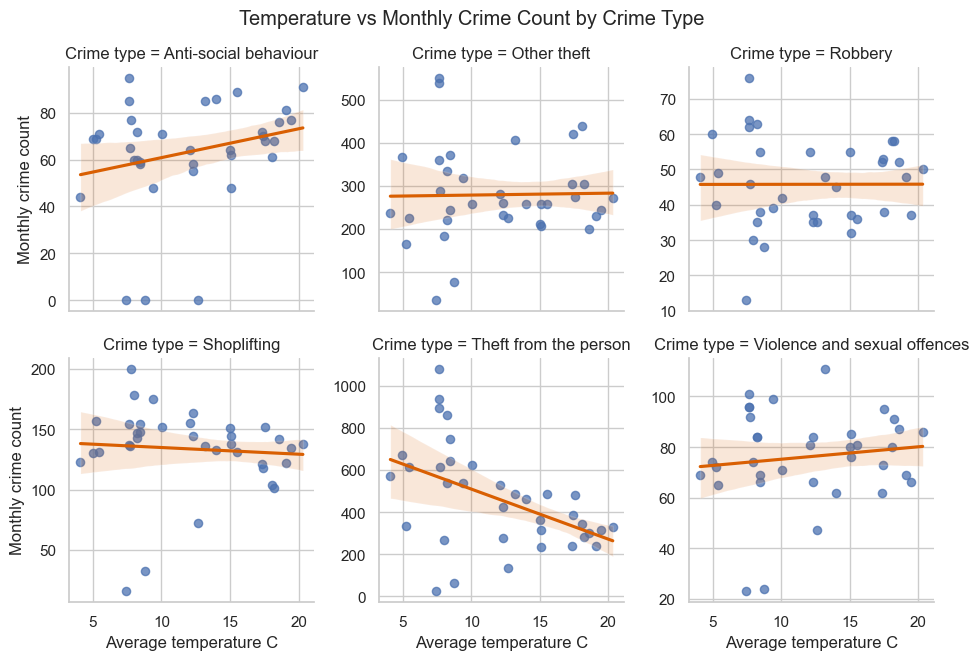

In [8]:
def prepare_target_lsoa_frame(
    monthly_counts: pd.DataFrame,
    monthly_temperature: pd.DataFrame,
    target_lsoa: str,
) -> pd.DataFrame:
    target = monthly_counts[monthly_counts["LSOA code"].eq(target_lsoa)].copy()


    target["Month"] = normalize_month(target["Month"])
    target["crime_count"] = pd.to_numeric(target["crime_count"], errors="coerce").fillna(0)

    temp = monthly_temperature[monthly_temperature["LSOA code"].eq(target_lsoa)].copy()

    temp["Month"] = normalize_month(temp["Month"])
    temp["avg_temperature_c"] = pd.to_numeric(temp["avg_temperature_c"], errors="coerce")
    temp = temp[["Month", "avg_temperature_c"]].drop_duplicates("Month")

    months = pd.date_range(target["Month"].min(), target["Month"].max(), freq="MS")
    crime_types = sorted(target["Crime type"].dropna().unique())
    grid = pd.MultiIndex.from_product(
        [months, crime_types], names=["Month", "Crime type"]
    ).to_frame(index=False)

    counts = (
        target.groupby(["Month", "Crime type"], as_index=False)["crime_count"]
        .sum()
        .merge(grid, on=["Month", "Crime type"], how="right")
    )
    counts["crime_count"] = counts["crime_count"].fillna(0).astype("int32")
    counts["LSOA code"] = target_lsoa
    counts["LSOA name"] = target["LSOA name"].dropna().mode().iloc[0]
    counts = counts.merge(temp, on="Month", how="left")

    if counts["avg_temperature_c"].isna().any():
        counts["avg_temperature_c"] = (
            counts.sort_values("Month")
            .groupby("Crime type")["avg_temperature_c"]
            .transform(lambda values: values.interpolate().ffill().bfill())
        )
        month_temp = counts.groupby(counts["Month"].dt.month)["avg_temperature_c"].transform("mean")
        counts["avg_temperature_c"] = counts["avg_temperature_c"].fillna(month_temp)
        counts["avg_temperature_c"] = counts["avg_temperature_c"].fillna(counts["avg_temperature_c"].mean())

    return counts.sort_values(["Crime type", "Month"]).reset_index(drop=True)


target_temperature_months = monthly_temperature.loc[
    monthly_temperature["LSOA code"].eq(TARGET_LSOA), "Month"
].pipe(normalize_month).nunique()
target_crime_months = monthly_counts.loc[
    monthly_counts["LSOA code"].eq(TARGET_LSOA), "Month"
].pipe(normalize_month).nunique()
temperature_has_full_coverage = target_temperature_months >= target_crime_months

if not temperature_has_full_coverage:
    print(
        "WARNING: Temperature data only covers "
        f"{target_temperature_months} of {target_crime_months} crime months. "
        "The missing months will be filled for model code, but temperature relationship plots/correlations are skipped. "
        "Set WEATHER_TEST_MODE = False and rerun the weather cell for a real temperature analysis."
    )

target_monthly = prepare_target_lsoa_frame(monthly_counts, monthly_temperature, TARGET_LSOA)

crime_type_distribution = (
    target_monthly.groupby("Crime type", as_index=False)["crime_count"]
    .sum()
    .sort_values("crime_count", ascending=False)
)

target_total_monthly = (
    target_monthly.groupby("Month", as_index=False)
    .agg(crime_count=("crime_count", "sum"), avg_temperature_c=("avg_temperature_c", "first"))
    .sort_values("Month")
)

print(f"Target LSOA: {TARGET_LSOA} / {target_monthly['LSOA name'].iloc[0]}")
display(crime_type_distribution)

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=target_total_monthly, x="Month", y="crime_count", marker="o", ax=ax1, label="Crime count")
ax1.set_ylabel("Crime count")
ax2 = ax1.twinx()
sns.lineplot(
    data=target_total_monthly,
    x="Month",
    y="avg_temperature_c",
    marker="s",
    color="#d95f02",
    ax=ax2,
    label="Average temperature C",
)
ax2.set_ylabel("Average temperature C")
ax1.set_title(f"Monthly Crime and Temperature for {TARGET_LSOA}")
fig.tight_layout()
plt.show()

if temperature_has_full_coverage:
    relationship_rows = []
    for crime_type, frame in target_monthly.groupby("Crime type", sort=False):
        if frame["crime_count"].nunique() < 2 or frame["avg_temperature_c"].nunique() < 2:
            pearson_corr = np.nan
            spearman_corr = np.nan
        else:
            pearson_corr = frame["crime_count"].corr(frame["avg_temperature_c"], method="pearson")
            spearman_corr = frame["crime_count"].corr(frame["avg_temperature_c"], method="spearman")
        relationship_rows.append(
            {
                "Crime type": crime_type,
                "months": len(frame),
                "total_crime": int(frame["crime_count"].sum()),
                "pearson_temp_vs_crime": pearson_corr,
                "spearman_temp_vs_crime": spearman_corr,
            }
        )

    temperature_relationship = (
        pd.DataFrame(relationship_rows)
        .sort_values("total_crime", ascending=False)
        .reset_index(drop=True)
    )
    print("Temperature and crime-count relationship by crime type")
    display(temperature_relationship)

    plot_data = target_monthly.merge(
        crime_type_distribution.head(6)[["Crime type"]],
        on="Crime type",
        how="inner",
    )

    if not plot_data.empty:
        grid = sns.lmplot(
            data=plot_data,
            x="avg_temperature_c",
            y="crime_count",
            col="Crime type",
            col_wrap=3,
            height=3.2,
            scatter_kws={"alpha": 0.75, "s": 35},
            line_kws={"color": "#d95f02"},
            facet_kws={"sharey": False, "sharex": True},
        )
        grid.set_axis_labels("Average temperature C", "Monthly crime count")
        grid.fig.suptitle("Temperature vs Monthly Crime Count by Crime Type", y=1.03)
        plt.show()
else:
    temperature_relationship = pd.DataFrame()


## Modeling Dependencies

SARIMA uses `statsmodels`, Prophet uses `prophet`, and XGBoost uses `xgboost`. The rolling cross-validation runs every model twice: once with `avg_temperature_c` and once without it, so the accuracy impact of temperature is visible.


In [9]:
from prophet import Prophet
from xgboost import XGBRegressor


Importing plotly failed. Interactive plots will not work.


## Rolling-Window Cross-Validation Functions


In [10]:
def rolling_folds(n_obs: int, train_size: int, horizon: int, step: int) -> list[tuple[int, np.ndarray, np.ndarray]]:
    folds: list[tuple[int, np.ndarray, np.ndarray]] = []
    fold_id = 1
    start = 0
    while start + train_size + horizon <= n_obs:
        train_idx = np.arange(start, start + train_size)
        test_idx = np.arange(start + train_size, start + train_size + horizon)
        folds.append((fold_id, train_idx, test_idx))
        fold_id += 1
        start += step
    return folds


def sarima_predict(train_frame: pd.DataFrame, future_frame: pd.DataFrame, use_temperature: bool = True) -> pd.Series:
    train = train_frame.sort_values("Month").copy()
    future = future_frame.sort_values("Month").copy()
    future_months = pd.DatetimeIndex(future["Month"])

    train_y = train.set_index("Month")["crime_count"].astype(float).asfreq("MS")
    train_exog = None
    future_exog = None
    if use_temperature:
        train_exog = train.set_index("Month")[["avg_temperature_c"]].astype(float).asfreq("MS")
        future_exog = future.set_index("Month")[["avg_temperature_c"]].astype(float).reindex(future_months)
        if train_exog["avg_temperature_c"].isna().any() or future_exog["avg_temperature_c"].isna().any():
            raise ValueError("SARIMA temperature regressor has missing values.")
    if len(train_y) < 18:
        raise ValueError("SARIMA needs at least 18 monthly observations for this notebook setup.")

    best_result = None
    best_aic = np.inf
    best_spec = None
    for order in SARIMA_ORDERS:
        for seasonal_order in SARIMA_SEASONAL_ORDERS:
            try:
                model = SARIMAX(
                    train_y,
                    exog=train_exog,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                result = model.fit(disp=False, maxiter=200)
                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_result = result
                    best_aic = result.aic
                    best_spec = (order, seasonal_order)
            except Exception:
                continue

    if best_result is None:
        raise RuntimeError("No SARIMA specification converged.")

    if use_temperature:
        forecast = best_result.get_forecast(steps=len(future_months), exog=future_exog).predicted_mean
    else:
        forecast = best_result.get_forecast(steps=len(future_months)).predicted_mean
    forecast.index = future_months
    forecast.attrs["spec"] = best_spec
    return forecast


def prophet_predict(train_frame: pd.DataFrame, future_frame: pd.DataFrame, use_temperature: bool = True) -> pd.Series:
    if Prophet is None:
        raise ImportError("prophet is not installed.")
    if train_frame["crime_count"].nunique() < 2:
        raise ValueError("Prophet needs at least two distinct y values.")

    train = train_frame.sort_values("Month").copy()
    future = future_frame.sort_values("Month").copy()
    if use_temperature:
        train["avg_temperature_c"] = pd.to_numeric(train["avg_temperature_c"], errors="coerce")
        future["avg_temperature_c"] = pd.to_numeric(future["avg_temperature_c"], errors="coerce")
        if train["avg_temperature_c"].isna().any() or future["avg_temperature_c"].isna().any():
            raise ValueError("Prophet temperature regressor has missing values.")

    prophet_columns = ["Month", "crime_count"] + (["avg_temperature_c"] if use_temperature else [])
    prophet_train = train[prophet_columns].rename(columns={"Month": "ds", "crime_count": "y"})
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )
    if use_temperature:
        model.add_regressor("avg_temperature_c")
    model.fit(prophet_train)
    if use_temperature:
        prophet_future = future[["Month", "avg_temperature_c"]].rename(columns={"Month": "ds"})
    else:
        prophet_future = future[["Month"]].rename(columns={"Month": "ds"})
    forecast = model.predict(prophet_future)
    return pd.Series(forecast["yhat"].to_numpy(), index=pd.DatetimeIndex(future["Month"]))


def xgb_feature_columns(use_temperature: bool = True) -> list[str]:
    if use_temperature:
        return XGB_FEATURE_COLUMNS
    return [column for column in XGB_FEATURE_COLUMNS if column != "avg_temperature_c"]


def make_xgb_training_frame(frame: pd.DataFrame, use_temperature: bool = True) -> pd.DataFrame:
    work = frame[["Month", "crime_count", "avg_temperature_c"]].copy().sort_values("Month")
    for lag in XGB_LAGS:
        work[f"lag_{lag}"] = work["crime_count"].shift(lag)
    work["rolling_3_mean"] = work["crime_count"].shift(1).rolling(3, min_periods=1).mean()
    work["rolling_6_mean"] = work["crime_count"].shift(1).rolling(6, min_periods=1).mean()
    work["rolling_12_mean"] = work["crime_count"].shift(1).rolling(12, min_periods=1).mean()
    month_feature_frame = work["Month"].apply(month_features).apply(pd.Series)
    work = pd.concat([work, month_feature_frame], axis=1)
    feature_columns = xgb_feature_columns(use_temperature)
    return work.dropna(subset=feature_columns + ["crime_count"])


def xgb_feature_row(
    history_values: list[float],
    month: pd.Timestamp,
    avg_temperature_c: float,
    use_temperature: bool = True,
) -> dict[str, float]:
    features = month_features(month)
    if use_temperature:
        features["avg_temperature_c"] = float(avg_temperature_c)
    for lag in XGB_LAGS:
        features[f"lag_{lag}"] = float(history_values[-lag]) if len(history_values) >= lag else np.nan
    history_series = pd.Series(history_values, dtype=float)
    features["rolling_3_mean"] = float(history_series.tail(3).mean())
    features["rolling_6_mean"] = float(history_series.tail(6).mean())
    features["rolling_12_mean"] = float(history_series.tail(12).mean())
    return features


def xgboost_predict(train_frame: pd.DataFrame, future_frame: pd.DataFrame, use_temperature: bool = True) -> pd.Series:

    feature_columns = xgb_feature_columns(use_temperature)
    train_features = make_xgb_training_frame(train_frame, use_temperature=use_temperature)
    if len(train_features) < 8:
        raise ValueError("XGBoost needs at least 8 usable lag-feature rows.")

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(train_features[feature_columns], train_features["crime_count"])

    history_values = train_frame.sort_values("Month")["crime_count"].astype(float).tolist()
    predictions: list[float] = []
    future_frame = future_frame.sort_values("Month")
    for row in future_frame.itertuples(index=False):
        feature_dict = xgb_feature_row(history_values, row.Month, row.avg_temperature_c, use_temperature=use_temperature)
        feature_frame = pd.DataFrame([feature_dict], columns=feature_columns)
        prediction = float(model.predict(feature_frame)[0])
        prediction = max(0.0, prediction)
        predictions.append(prediction)
        history_values.append(prediction)

    return pd.Series(predictions, index=pd.DatetimeIndex(future_frame["Month"]))


def forecast_with_model(
    model_name: str,
    train_frame: pd.DataFrame,
    future_frame: pd.DataFrame,
    use_temperature: bool = True,
) -> pd.Series:
    if model_name == "SARIMA":
        return sarima_predict(train_frame, future_frame, use_temperature=use_temperature)
    if model_name == "Prophet":
        return prophet_predict(train_frame, future_frame, use_temperature=use_temperature)
    if model_name == "XGBoost":
        return xgboost_predict(train_frame, future_frame, use_temperature=use_temperature)
    raise ValueError(f"Unknown model: {model_name}")


def evaluate_crime_type(frame: pd.DataFrame, crime_type: str) -> tuple[list[dict], list[dict]]:
    frame = frame.sort_values("Month").reset_index(drop=True)
    folds = rolling_folds(
        len(frame),
        train_size=ROLLING_TRAIN_MONTHS,
        horizon=ROLLING_TEST_MONTHS,
        step=ROLLING_STEP_MONTHS,
    )

    metric_rows: list[dict] = []
    forecast_rows: list[dict] = []
    for fold_id, train_idx, test_idx in folds:
        train_frame = frame.iloc[train_idx].copy()
        test_frame = frame.iloc[test_idx].copy()
        actual = test_frame["crime_count"].astype(float).to_numpy()

        for model_name in ["SARIMA", "XGBoost", "Prophet"]:
            for temperature_setting, use_temperature in [
                ("with_temperature", True),
                ("without_temperature", False),
            ]:
                row_base = {
                    "Crime type": crime_type,
                    "model": model_name,
                    "temperature_setting": temperature_setting,
                    "uses_temperature": use_temperature,
                    "fold": fold_id,
                    "train_start": train_frame["Month"].min(),
                    "train_end": train_frame["Month"].max(),
                    "test_start": test_frame["Month"].min(),
                    "test_end": test_frame["Month"].max(),
                }

                predicted_series = forecast_with_model(
                    model_name,
                    train_frame,
                    test_frame,
                    use_temperature=use_temperature,
                )
                predicted = np.clip(predicted_series.to_numpy(dtype=float), 0, None)
                metrics = regression_metrics(actual, predicted)
                metric_rows.append({**row_base, **metrics, "status": "ok", "error": ""})

                for month, observed, prediction in zip(test_frame["Month"], actual, predicted):
                    forecast_rows.append(
                        {
                            "Crime type": crime_type,
                            "model": model_name,
                            "temperature_setting": temperature_setting,
                            "uses_temperature": use_temperature,
                            "fold": fold_id,
                            "Month": month,
                            "actual": float(observed),
                            "predicted": float(prediction),
                            "status": "ok",
                            "error": "",
                        }
                    )


    return metric_rows, forecast_rows


## Run Rolling-Window Cross-Validation for Every Crime Type


In [11]:
all_metric_rows: list[dict] = []
all_forecast_rows: list[dict] = []

for crime_type, crime_frame in tqdm(
    target_monthly.groupby("Crime type", sort=True),
    total=target_monthly["Crime type"].nunique(),
    desc="Evaluating crime types",
):
    metric_rows, forecast_rows = evaluate_crime_type(crime_frame, crime_type)
    all_metric_rows.extend(metric_rows)
    all_forecast_rows.extend(forecast_rows)

metrics_df = pd.DataFrame(all_metric_rows)
forecasts_df = pd.DataFrame(all_forecast_rows)

metrics_df.to_csv(MODEL_COMPARISON_CACHE, index=False)
forecasts_df.to_csv(CV_FORECAST_CACHE, index=False)

print(f"Wrote model comparison cache: {MODEL_COMPARISON_CACHE}")
print(f"Wrote cross-validation forecast cache: {CV_FORECAST_CACHE}")

display(metrics_df.head(20))


Evaluating crime types:   0%|          | 0/14 [00:00<?, ?it/s]17:47:08 - cmdstanpy - INFO - Chain [1] start processing
17:47:15 - cmdstanpy - INFO - Chain [1] done processing
17:47:15 - cmdstanpy - INFO - Chain [1] start processing
17:47:15 - cmdstanpy - INFO - Chain [1] done processing
17:47:16 - cmdstanpy - INFO - Chain [1] start processing
17:47:16 - cmdstanpy - INFO - Chain [1] done processing
17:47:16 - cmdstanpy - INFO - Chain [1] start processing
17:47:23 - cmdstanpy - INFO - Chain [1] done processing
17:47:23 - cmdstanpy - INFO - Chain [1] start processing
17:47:31 - cmdstanpy - INFO - Chain [1] done processing
17:47:31 - cmdstanpy - INFO - Chain [1] start processing
17:47:36 - cmdstanpy - INFO - Chain [1] done processing
17:47:36 - cmdstanpy - INFO - Chain [1] start processing
17:47:43 - cmdstanpy - INFO - Chain [1] done processing
17:47:44 - cmdstanpy - INFO - Chain [1] start processing
17:47:44 - cmdstanpy - INFO - Chain [1] done processing
Evaluating crime types:   7%|▋    

Wrote model comparison cache: /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_crime_type_model_comparison.csv
Wrote cross-validation forecast cache: /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_crime_type_forecasts.csv


,Crime type,model,temperature_setting,uses_temperature,fold,train_start,train_end,test_start,test_end,mae,rmse,smape,status,error
0,Anti-social behaviour,SARIMA,with_temperature,True,1,2023-03-01,2025-02-01,2025-03-01,2025-05-01,22.58,24.64,30.83,ok,
1,Anti-social behaviour,SARIMA,without_temperature,False,1,2023-03-01,2025-02-01,2025-03-01,2025-05-01,13.49,15.89,19.41,ok,
2,Anti-social behaviour,XGBoost,with_temperature,True,1,2023-03-01,2025-02-01,2025-03-01,2025-05-01,14.92,16.51,21.82,ok,
3,Anti-social behaviour,XGBoost,without_temperature,False,1,2023-03-01,2025-02-01,2025-03-01,2025-05-01,14.53,16.13,21.28,ok,
4,Anti-social behaviour,Prophet,with_temperature,True,1,2023-03-01,2025-02-01,2025-03-01,2025-05-01,195.88,218.71,114.75,ok,
5,Anti-social behaviour,Prophet,without_temperature,False,1,2023-03-01,2025-02-01,2025-03-01,2025-05-01,6.90,7.67,10.79,ok,
6,Anti-social behaviour,SARIMA,with_temperature,True,2,2023-06-01,2025-05-01,2025-06-01,2025-08-01,13.19,18.06,17.34,ok,
7,Anti-social behaviour,SARIMA,without_temperature,False,2,2023-06-01,2025-05-01,2025-06-01,2025-08-01,12.28,14.52,15.39,ok,
8,Anti-social behaviour,XGBoost,with_temperature,True,2,2023-06-01,2025-05-01,2025-06-01,2025-08-01,9.07,11.11,11.28,ok,
9,Anti-social behaviour,XGBoost,without_temperature,False,2,2023-06-01,2025-05-01,2025-06-01,2025-08-01,15.15,18.22,20.02,ok,


## Compare SARIMA, XGBoost, and Prophet


Overall model comparison across crime types, folds, and temperature settings


,model,temperature_setting,mae,rmse,smape,evaluated_folds
5,XGBoost,without_temperature,19.88,21.88,37.37,56
4,XGBoost,with_temperature,21.75,23.43,38.09,56
3,SARIMA,without_temperature,25.32,27.17,42.08,56
2,SARIMA,with_temperature,25.88,28.12,42.82,56
1,Prophet,without_temperature,26.04,27.91,45.43,56
0,Prophet,with_temperature,85.85,93.77,66.54,56


Per-crime-type model comparison


,Crime type,model,temperature_setting,mae,rmse,smape,folds
4,Anti-social behaviour,XGBoost,with_temperature,11.21,12.63,16.98,4
5,Anti-social behaviour,XGBoost,without_temperature,13.20,14.71,19.82,4
3,Anti-social behaviour,SARIMA,without_temperature,13.82,15.93,21.15,4
1,Anti-social behaviour,Prophet,without_temperature,15.74,18.17,23.68,4
2,Anti-social behaviour,SARIMA,with_temperature,15.93,19.03,24.08,4
0,Anti-social behaviour,Prophet,with_temperature,69.60,76.76,59.13,4
7,Bicycle theft,Prophet,without_temperature,2.23,2.45,56.04,4
10,Bicycle theft,XGBoost,with_temperature,2.23,2.43,54.37,4
11,Bicycle theft,XGBoost,without_temperature,2.51,2.67,64.04,4
9,Bicycle theft,SARIMA,without_temperature,2.66,3.30,54.29,4


Negative change means temperature improved the metric


,model,mae_change_with_temp,rmse_change_with_temp,smape_change_with_temp
model,,,,
Prophet,Prophet,59.82,65.86,21.12
SARIMA,SARIMA,0.56,0.95,0.75
XGBoost,XGBoost,1.87,1.55,0.73


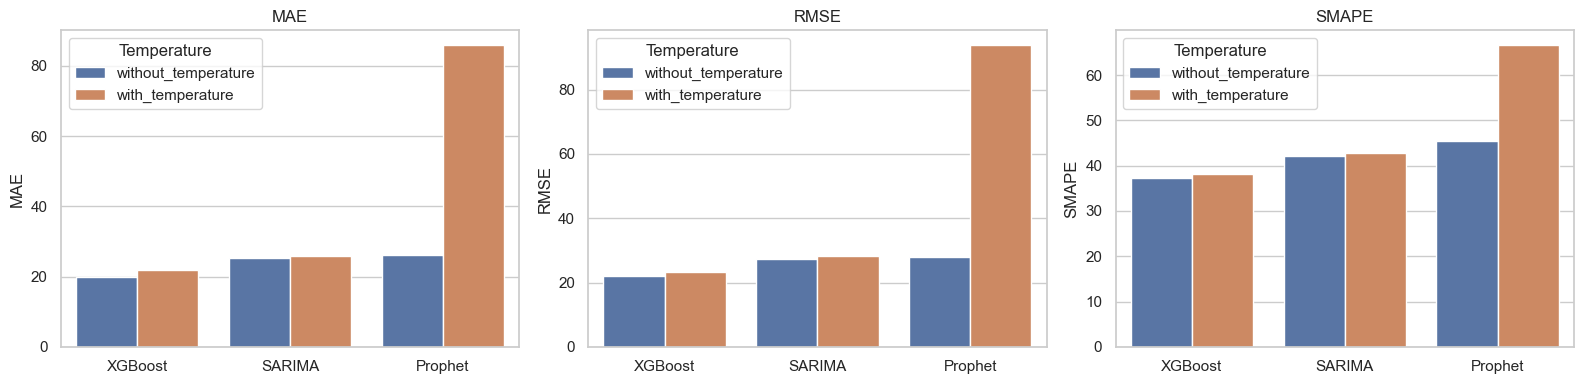

In [12]:
ok_metrics = metrics_df[metrics_df["status"].eq("ok")].copy()
failed_metrics = metrics_df[metrics_df["status"].ne("ok")].copy()

comparison_summary = (
    ok_metrics.groupby(["Crime type", "model", "temperature_setting"], as_index=False)
    .agg(
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
        folds=("fold", "nunique"),
    )
    .sort_values(["Crime type", "mae"])
)

overall_summary = (
    ok_metrics.groupby(["model", "temperature_setting"], as_index=False)
    .agg(
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
        evaluated_folds=("fold", "count"),
    )
    .sort_values("mae")
)

print("Overall model comparison across crime types, folds, and temperature settings")
display(overall_summary)

print("Per-crime-type model comparison")
display(comparison_summary)

temperature_effect = (
    overall_summary.pivot(index="model", columns="temperature_setting", values=["mae", "rmse", "smape"])
    .sort_index(axis=1)
)
if {"with_temperature", "without_temperature"}.issubset(set(overall_summary["temperature_setting"])):
    temperature_effect_delta = pd.DataFrame(
        {
            "model": temperature_effect.index,
            "mae_change_with_temp": temperature_effect[("mae", "with_temperature")] - temperature_effect[("mae", "without_temperature")],
            "rmse_change_with_temp": temperature_effect[("rmse", "with_temperature")] - temperature_effect[("rmse", "without_temperature")],
            "smape_change_with_temp": temperature_effect[("smape", "with_temperature")] - temperature_effect[("smape", "without_temperature")],
        }
    )
    print("Negative change means temperature improved the metric")
    display(temperature_effect_delta)

if not failed_metrics.empty:
    print("Failed model/fold rows")
    display(failed_metrics[["Crime type", "model", "temperature_setting", "fold", "status", "error"]].drop_duplicates().head(50))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["mae", "rmse", "smape"]):
    sns.barplot(data=overall_summary, x="model", y=metric, hue="temperature_setting", ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())
    ax.legend(title="Temperature")
plt.tight_layout()
plt.show()


## Cross-Validation Prediction Plots by Crime Type


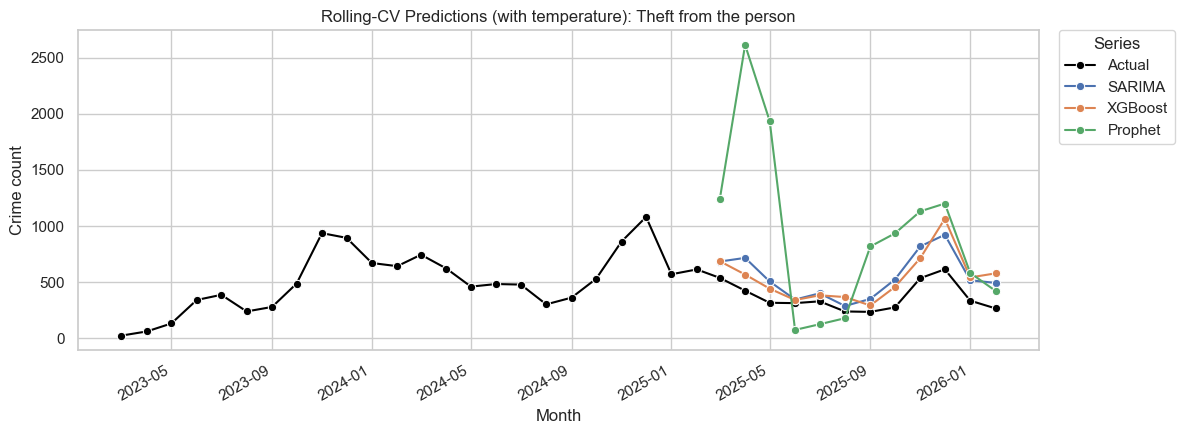

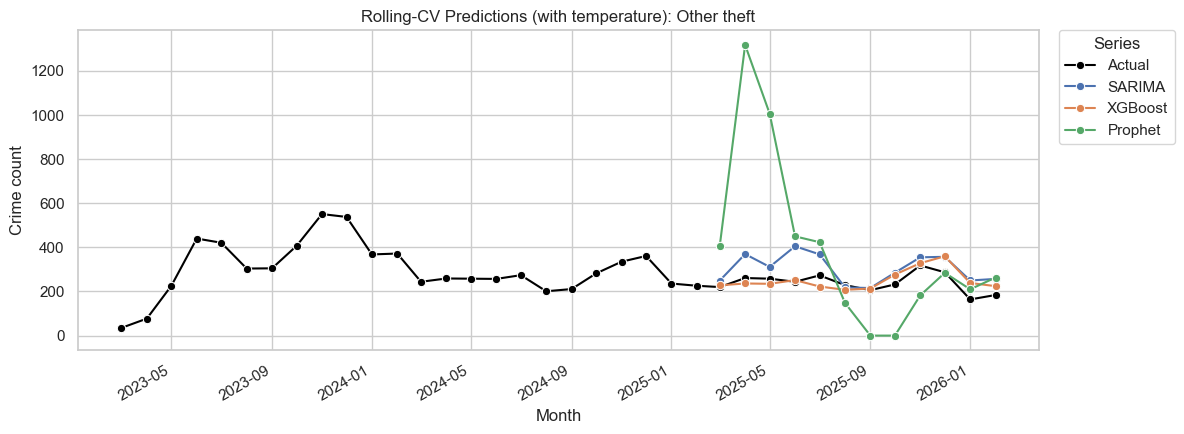

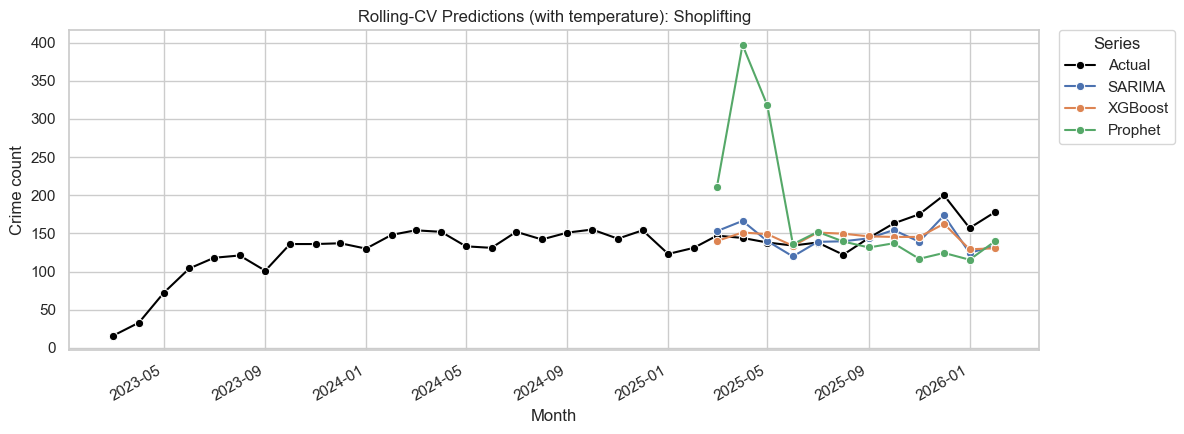

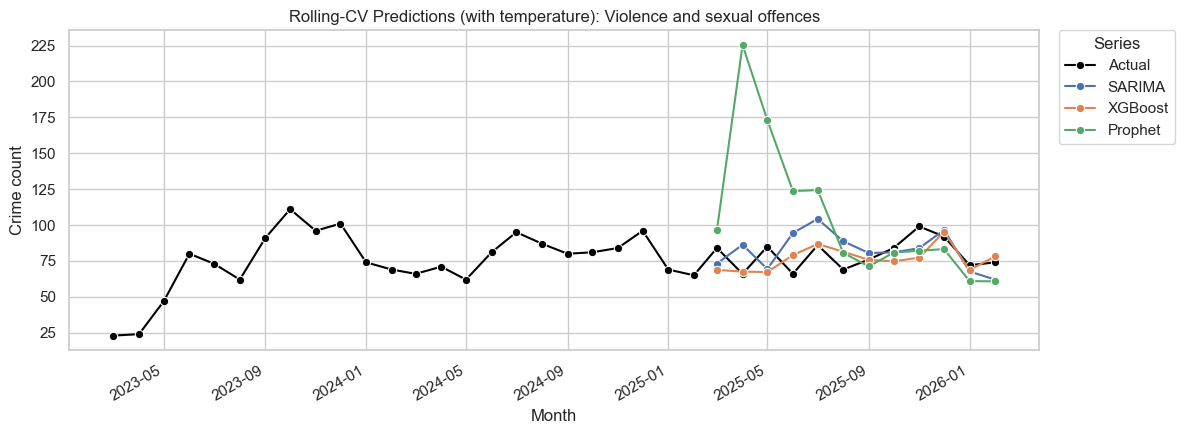

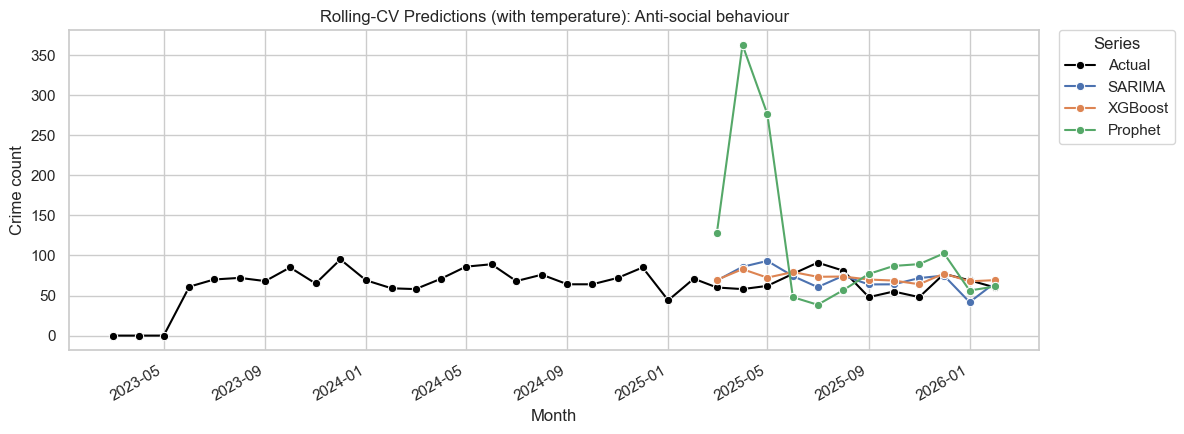

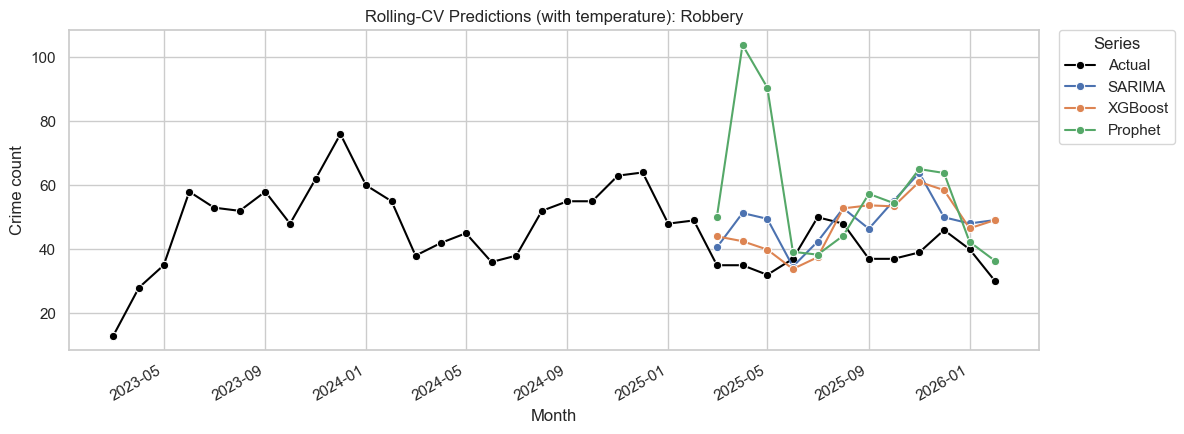

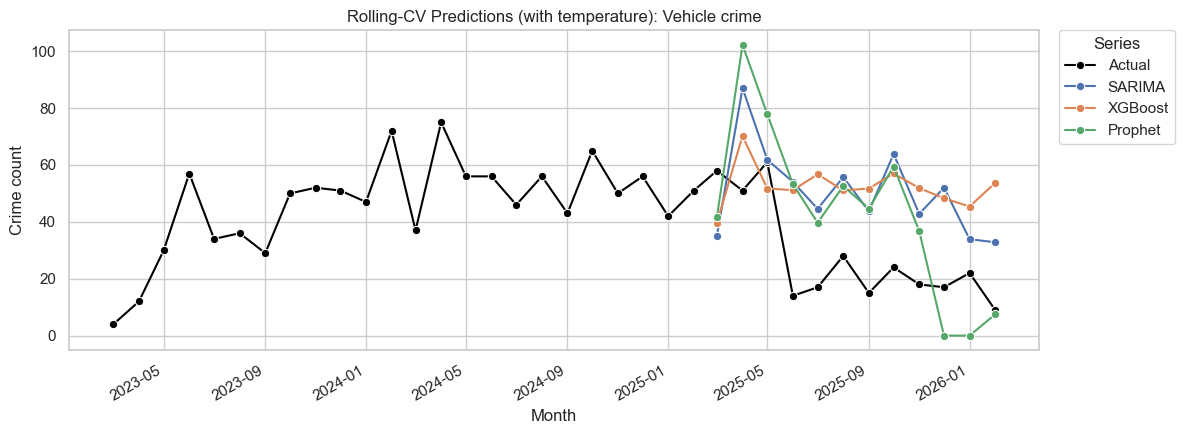

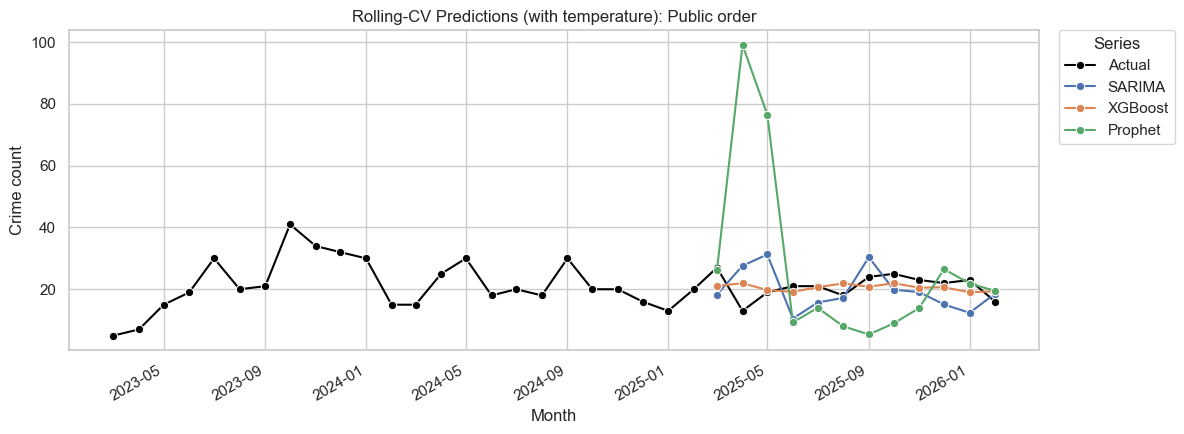

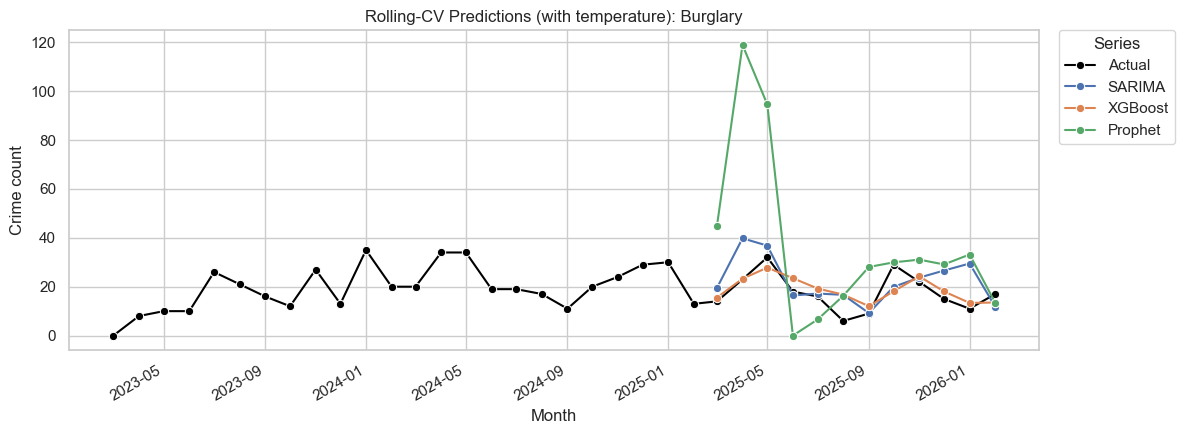

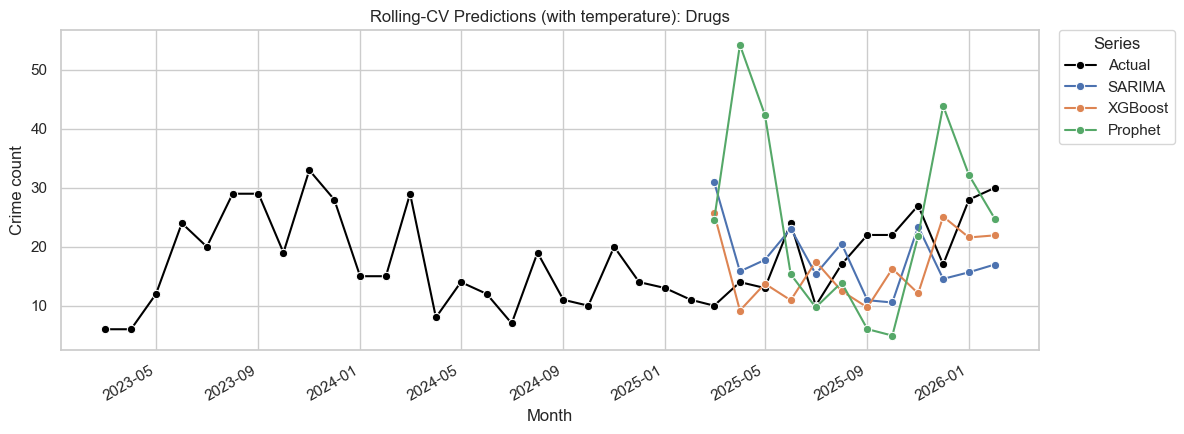

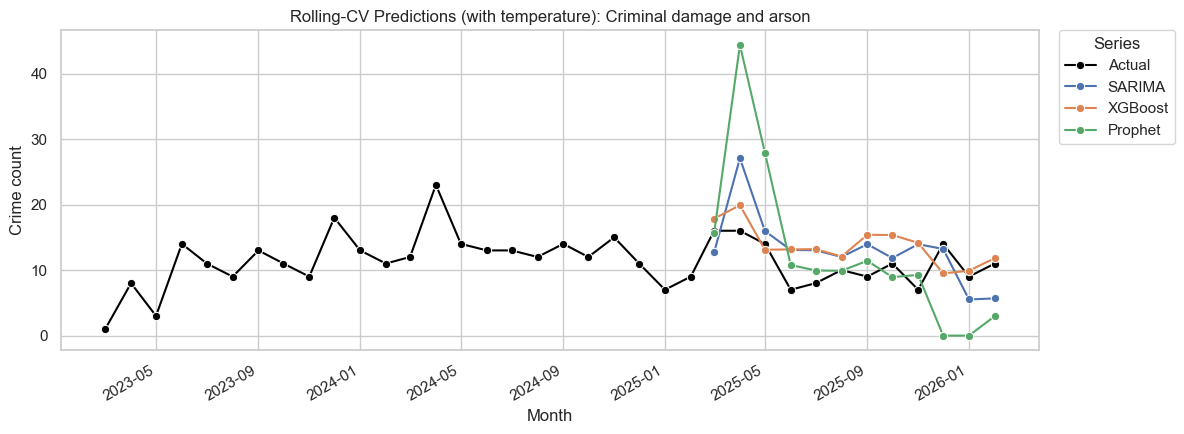

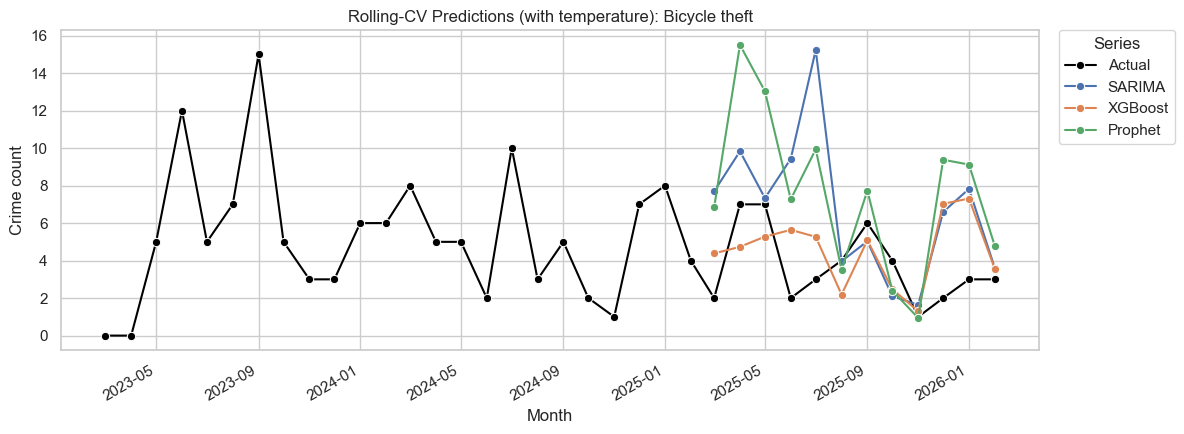

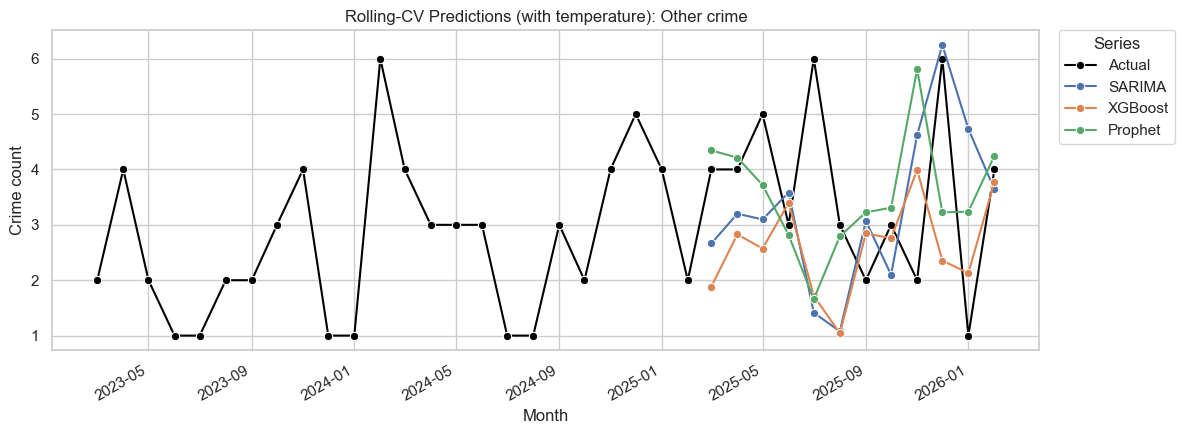

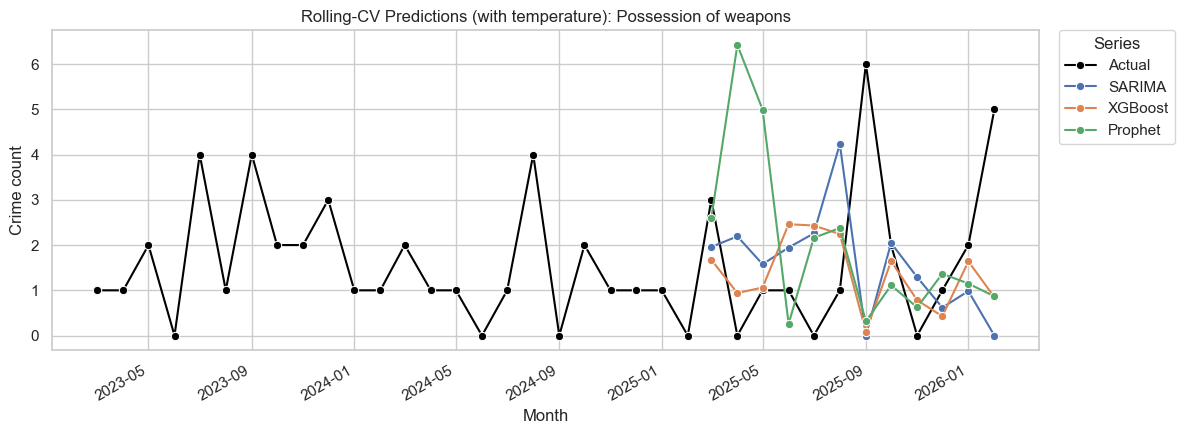

In [13]:
def plot_cv_predictions_for_crime_type(crime_type: str, temperature_setting: str, title_suffix: str) -> None:
    actual = target_monthly[target_monthly["Crime type"].eq(crime_type)].sort_values("Month")
    predictions = forecasts_df[
        forecasts_df["Crime type"].eq(crime_type)
        & forecasts_df["status"].eq("ok")
        & forecasts_df["temperature_setting"].eq(temperature_setting)
    ].copy()

    plt.figure(figsize=(12, 4.5))
    sns.lineplot(data=actual, x="Month", y="crime_count", color="black", marker="o", label="Actual")
    if not predictions.empty:
        sns.lineplot(
            data=predictions,
            x="Month",
            y="predicted",
            hue="model",
            marker="o",
            estimator="mean",
            errorbar=None,
        )
    plt.title(f"Rolling-CV Predictions ({title_suffix}): {crime_type}")
    plt.xlabel("Month")
    plt.ylabel("Crime count")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Series", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()


for crime_type in crime_type_distribution["Crime type"]:
    plot_cv_predictions_for_crime_type(crime_type, "with_temperature", "with temperature")


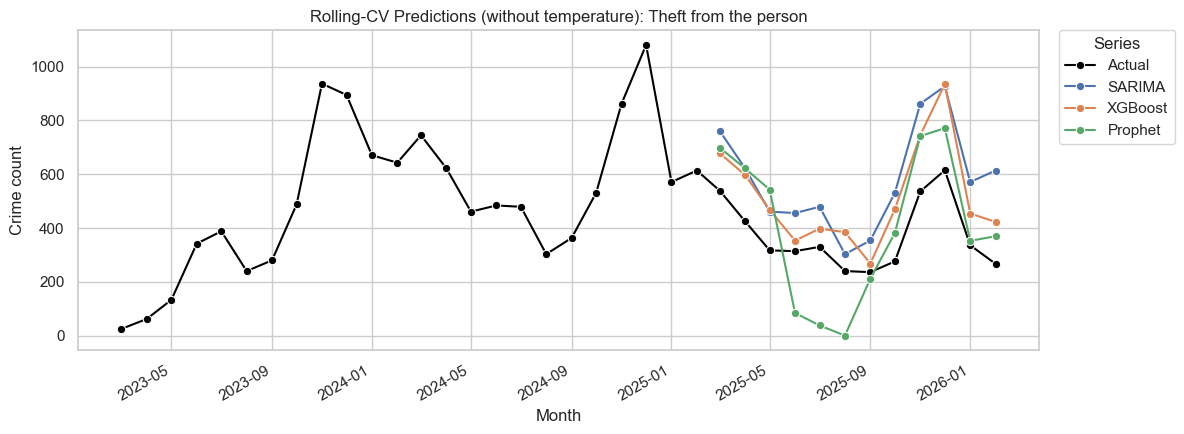

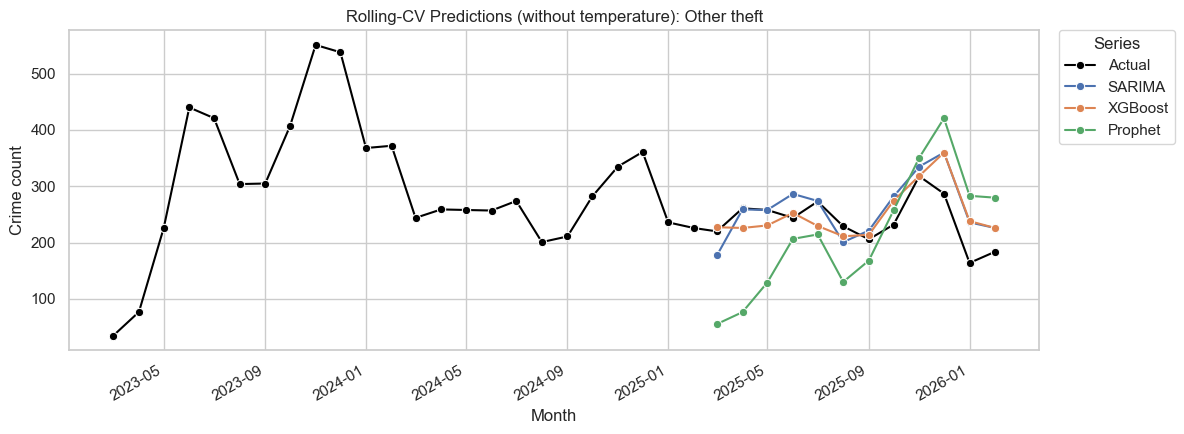

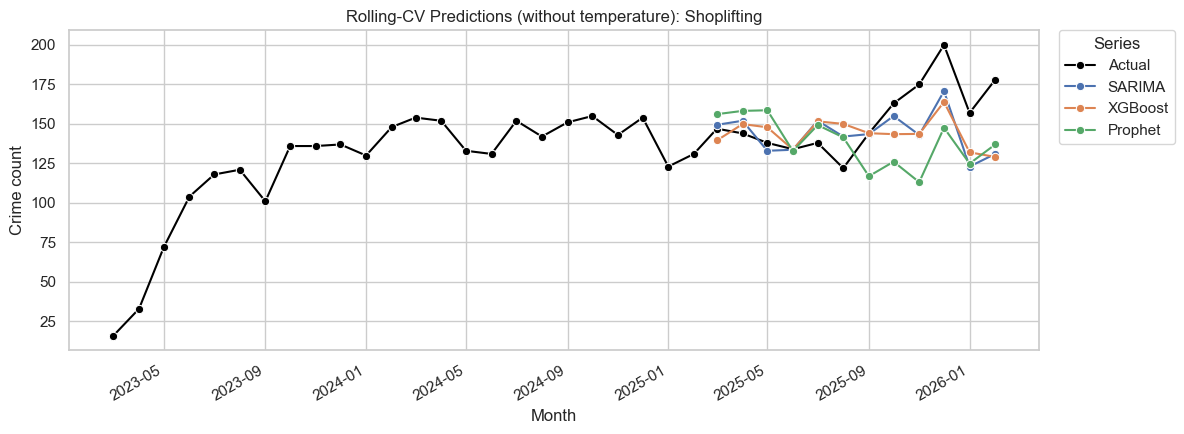

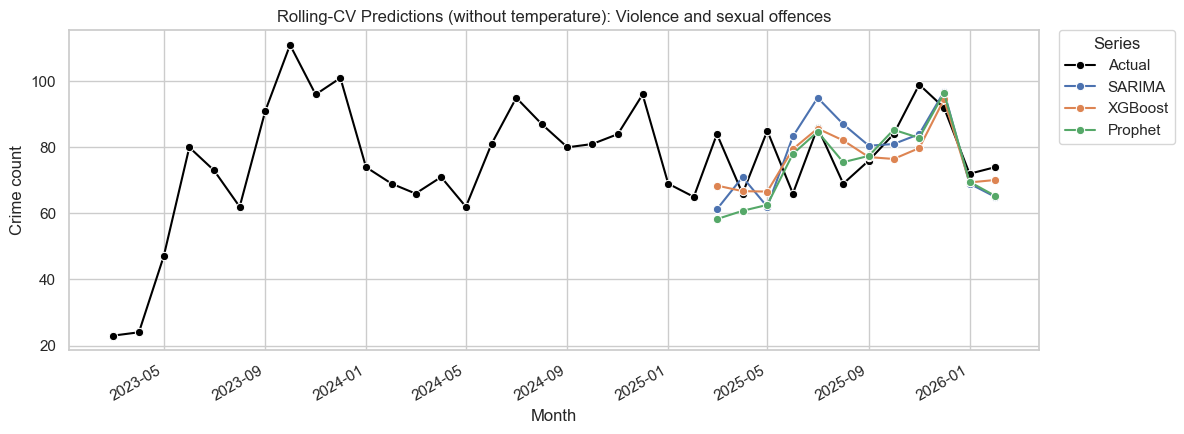

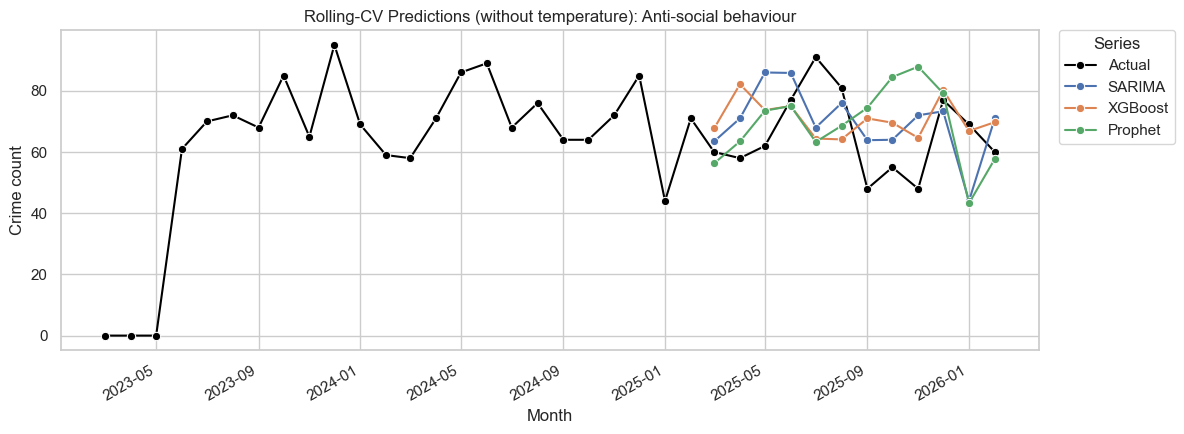

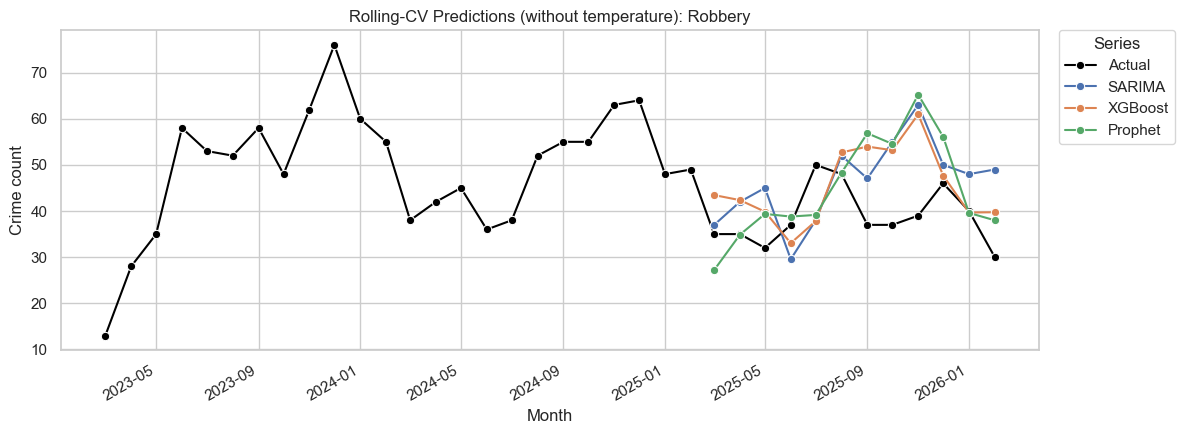

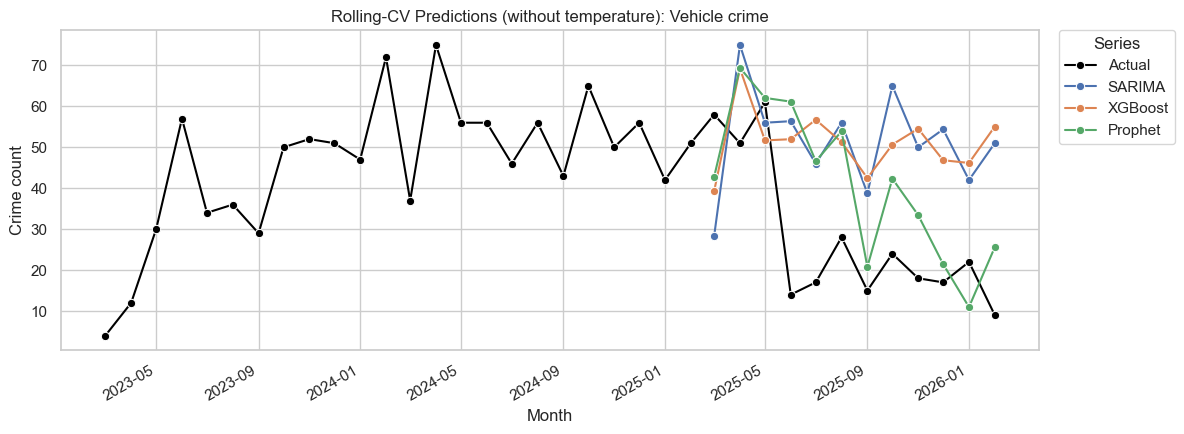

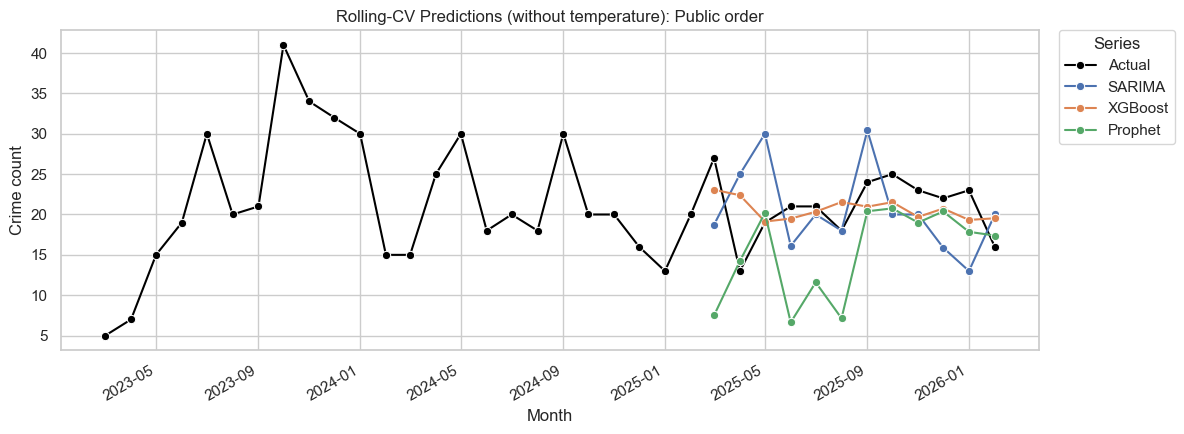

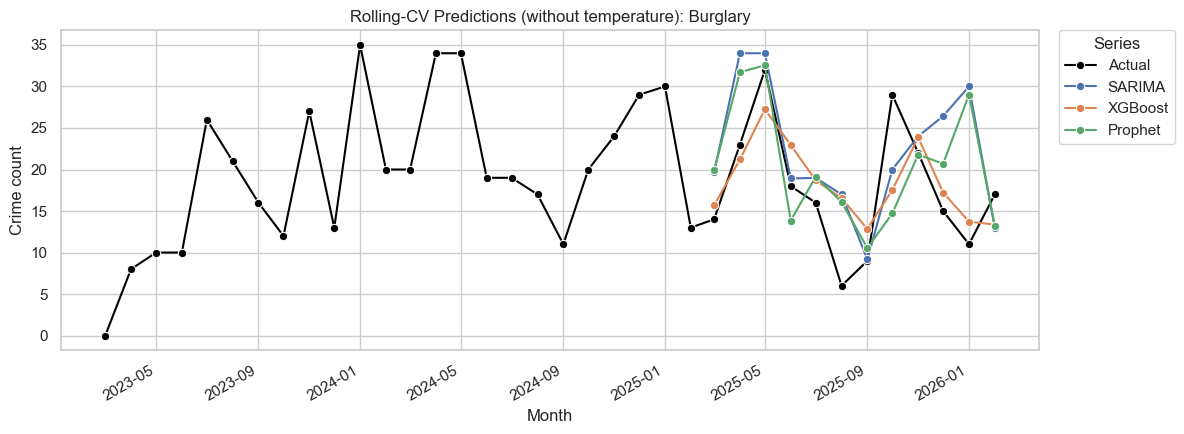

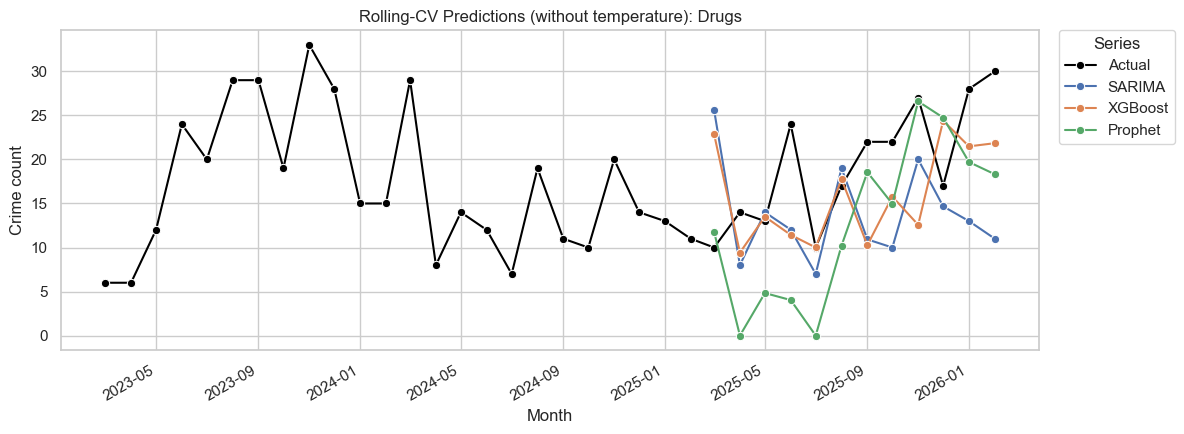

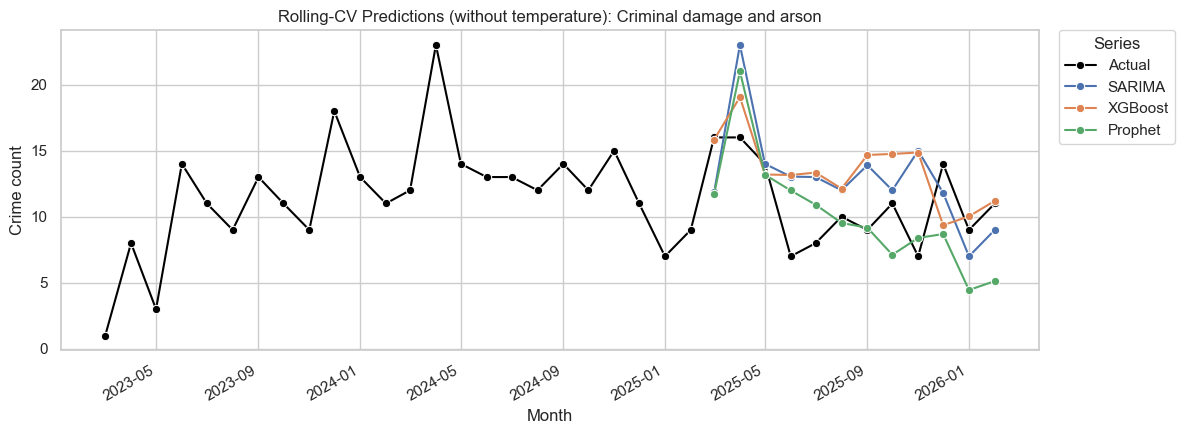

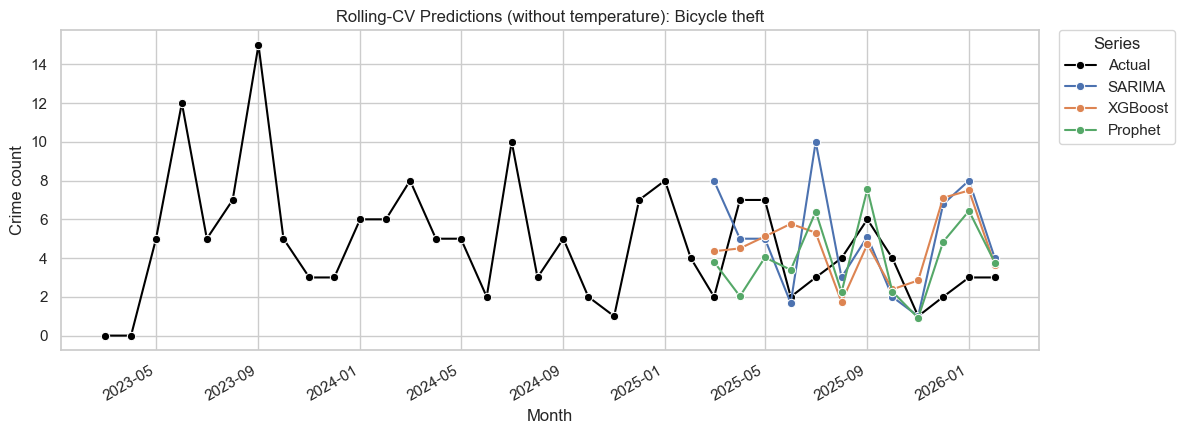

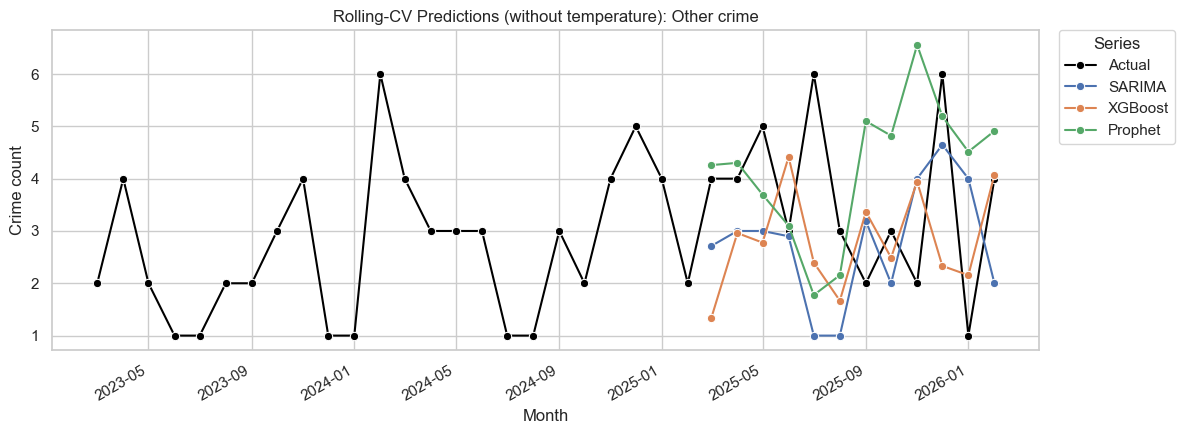

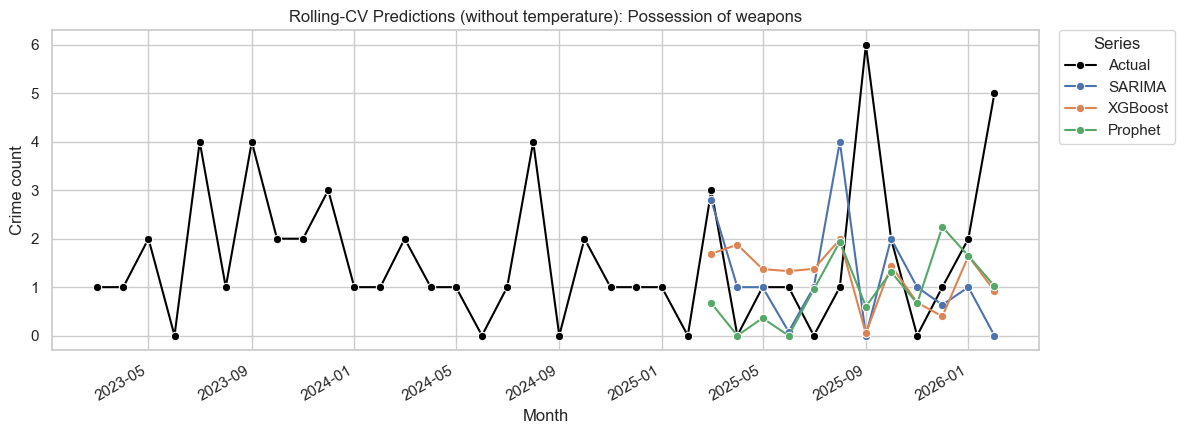

In [14]:
for crime_type in crime_type_distribution["Crime type"]:
    plot_cv_predictions_for_crime_type(crime_type, "without_temperature", "without temperature")


## Final Six-Month Forecasts by Crime Type

Because the rolling-CV comparison performed better without the temperature regressor, the final forecasts fit SARIMA, XGBoost, and Prophet with `use_temperature=False`.


In [15]:
def future_temperature_frame(target_frame: pd.DataFrame, future_months: pd.DatetimeIndex) -> pd.DataFrame:
    climatology = target_frame.groupby(target_frame["Month"].dt.month)["avg_temperature_c"].mean()
    fallback = float(target_frame["avg_temperature_c"].mean())
    return pd.DataFrame(
        {
            "Month": future_months,
            "avg_temperature_c": [float(climatology.get(month.month, fallback)) for month in future_months],
        }
    )


future_rows: list[dict] = []
last_month = target_monthly["Month"].max()
future_months = pd.date_range(last_month + pd.offsets.MonthBegin(1), periods=FINAL_FORECAST_HORIZON, freq="MS")
base_future_temperature = future_temperature_frame(target_monthly, future_months)

for crime_type, crime_frame in tqdm(
    target_monthly.groupby("Crime type", sort=True),
    total=target_monthly["Crime type"].nunique(),
    desc="Final forecasts",
):
    train_frame = crime_frame.sort_values("Month").copy()
    future_frame = base_future_temperature.copy()
    for model_name in ["SARIMA", "XGBoost", "Prophet"]:

        predicted = forecast_with_model(model_name, train_frame, future_frame, use_temperature=False)
        values = np.clip(predicted.to_numpy(dtype=float), 0, None)
        for month, prediction in zip(future_months, values):
            future_rows.append(
                {
                    "Crime type": crime_type,
                    "model": model_name,
                    "temperature_setting": "without_temperature",
                    "uses_temperature": False,
                    "Month": month,
                    "predicted": float(prediction),
                    "status": "ok",
                    "error": "",
                }
            )


future_forecasts_df = pd.DataFrame(future_rows)
future_forecasts_df.to_csv(FUTURE_FORECAST_CACHE, index=False)
print(f"Wrote future forecast cache: {FUTURE_FORECAST_CACHE}")
display(future_forecasts_df.head(30))


Final forecasts:   0%|          | 0/14 [00:00<?, ?it/s]17:53:03 - cmdstanpy - INFO - Chain [1] start processing
17:53:03 - cmdstanpy - INFO - Chain [1] done processing
Final forecasts:   7%|▋         | 1/14 [00:00<00:06,  1.87it/s]17:53:04 - cmdstanpy - INFO - Chain [1] start processing
17:53:04 - cmdstanpy - INFO - Chain [1] done processing
Final forecasts:  14%|█▍        | 2/14 [00:00<00:05,  2.21it/s]17:53:04 - cmdstanpy - INFO - Chain [1] start processing
17:53:04 - cmdstanpy - INFO - Chain [1] done processing
Final forecasts:  21%|██▏       | 3/14 [00:01<00:04,  2.25it/s]17:53:04 - cmdstanpy - INFO - Chain [1] start processing
17:53:05 - cmdstanpy - INFO - Chain [1] done processing
Final forecasts:  29%|██▊       | 4/14 [00:01<00:04,  2.22it/s]17:53:05 - cmdstanpy - INFO - Chain [1] start processing
17:53:05 - cmdstanpy - INFO - Chain [1] done processing
Final forecasts:  36%|███▌      | 5/14 [00:02<00:03,  2.32it/s]17:53:05 - cmdstanpy - INFO - Chain [1] start processing
17:53:05

Wrote future forecast cache: /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_crime_type_future_forecasts.csv


,Crime type,model,temperature_setting,uses_temperature,Month,predicted,status,error
0,Anti-social behaviour,SARIMA,without_temperature,False,2026-03-01,56.58,ok,
1,Anti-social behaviour,SARIMA,without_temperature,False,2026-04-01,55.97,ok,
2,Anti-social behaviour,SARIMA,without_temperature,False,2026-05-01,61.81,ok,
3,Anti-social behaviour,SARIMA,without_temperature,False,2026-06-01,77.15,ok,
4,Anti-social behaviour,SARIMA,without_temperature,False,2026-07-01,84.30,ok,
5,Anti-social behaviour,SARIMA,without_temperature,False,2026-08-01,78.36,ok,
6,Anti-social behaviour,XGBoost,without_temperature,False,2026-03-01,59.40,ok,
7,Anti-social behaviour,XGBoost,without_temperature,False,2026-04-01,67.28,ok,
8,Anti-social behaviour,XGBoost,without_temperature,False,2026-05-01,84.54,ok,
9,Anti-social behaviour,XGBoost,without_temperature,False,2026-06-01,83.91,ok,


## Future Forecast Plots


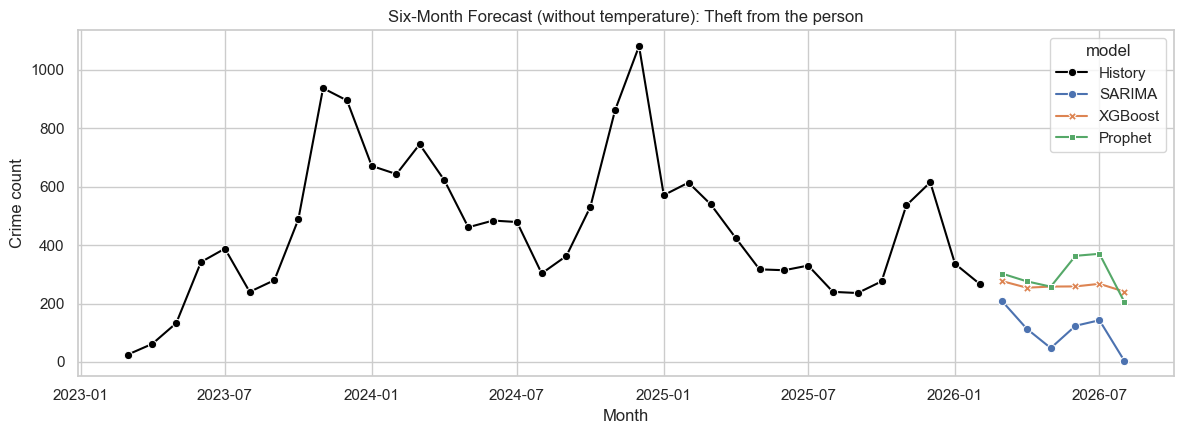

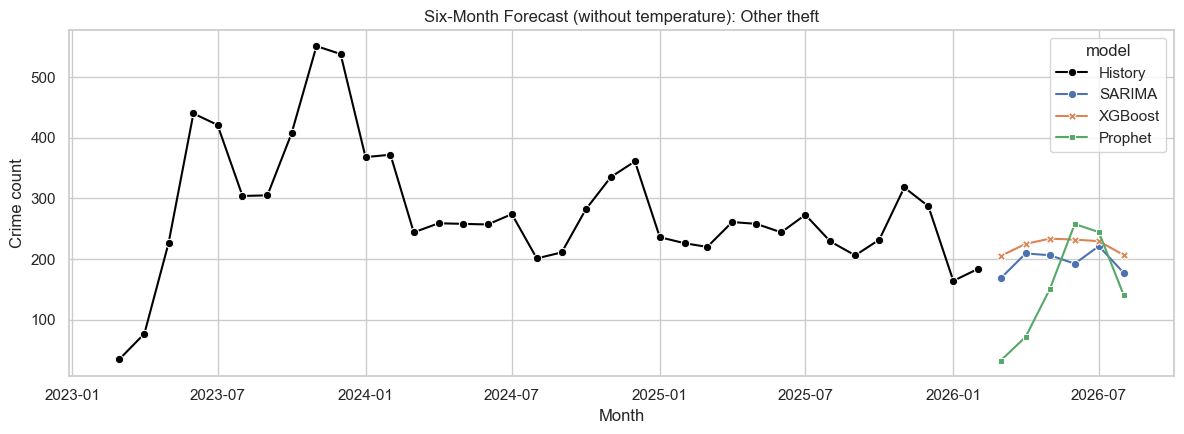

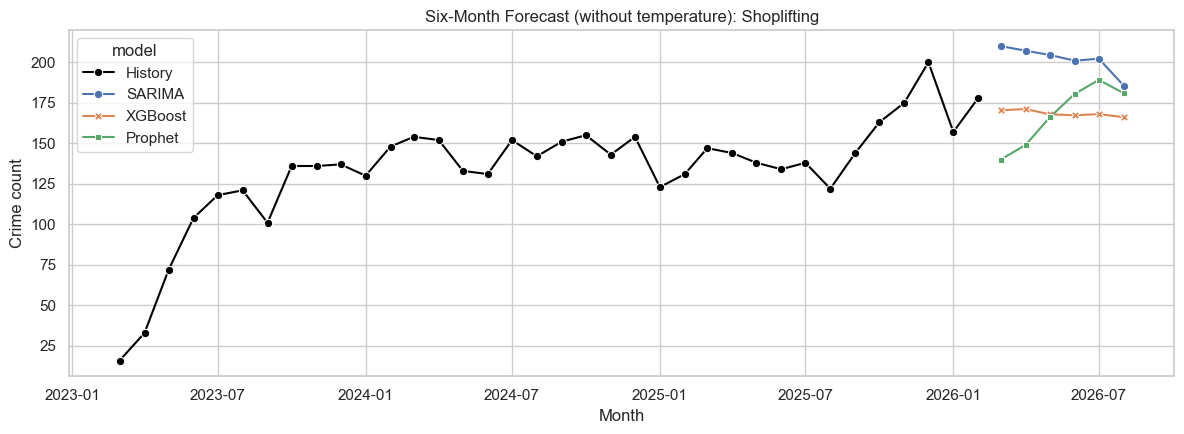

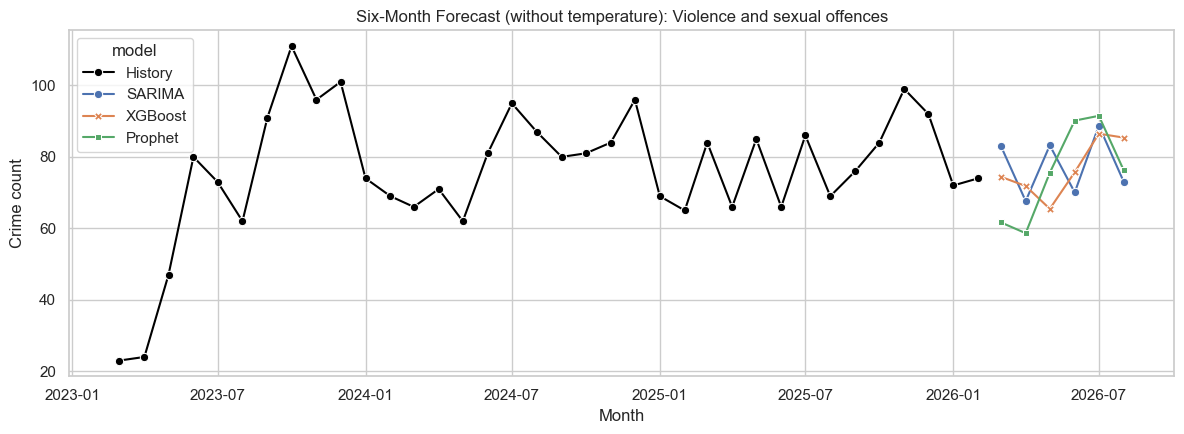

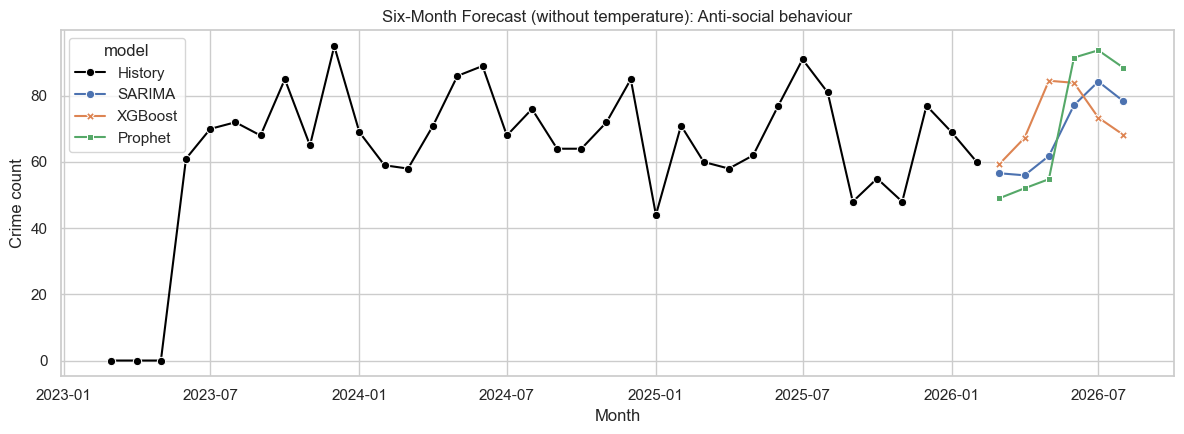

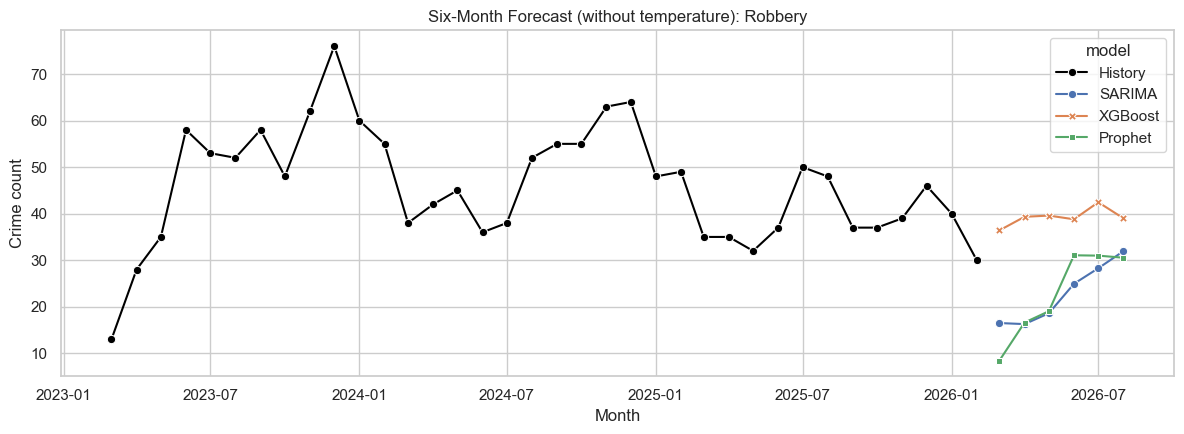

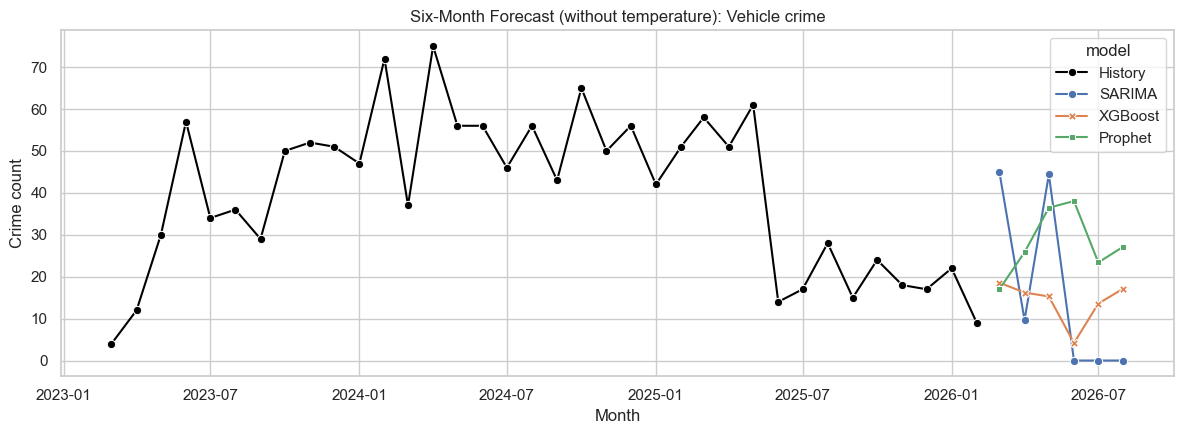

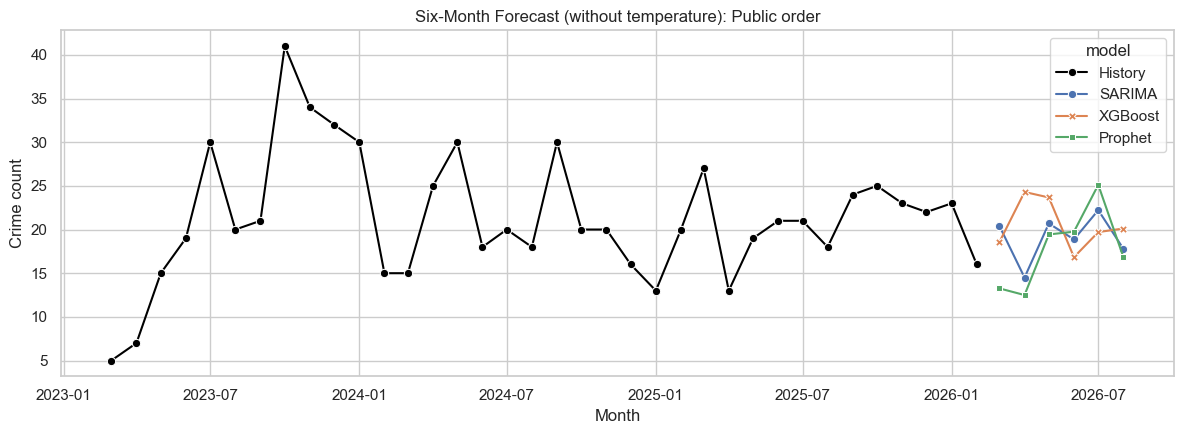

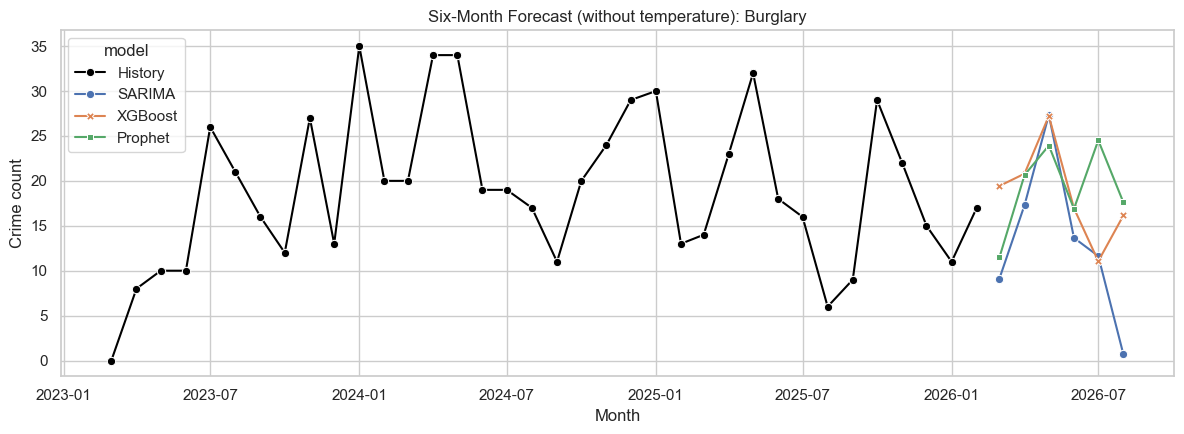

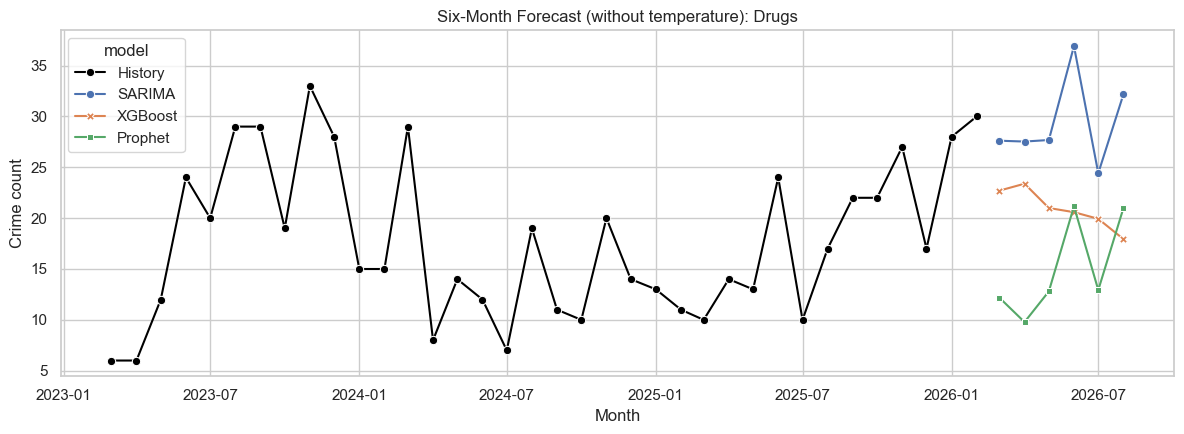

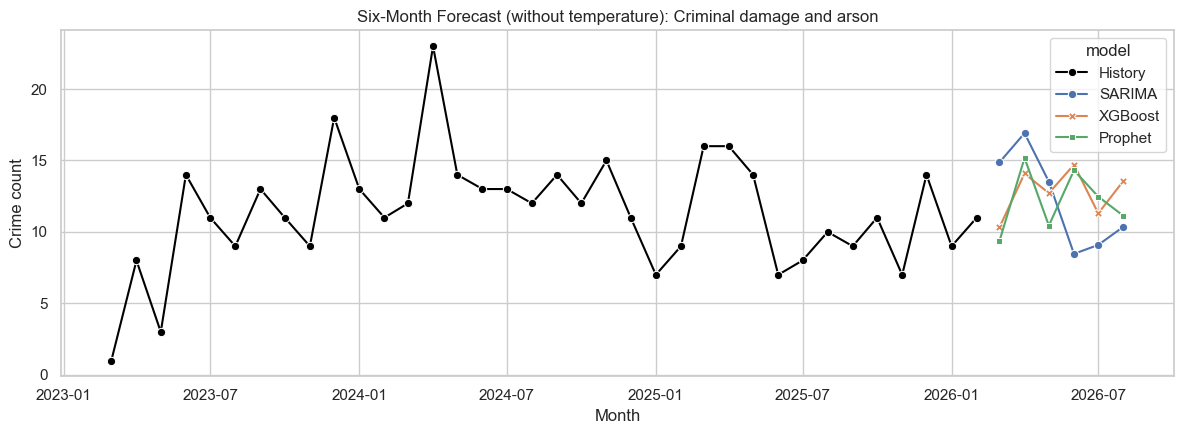

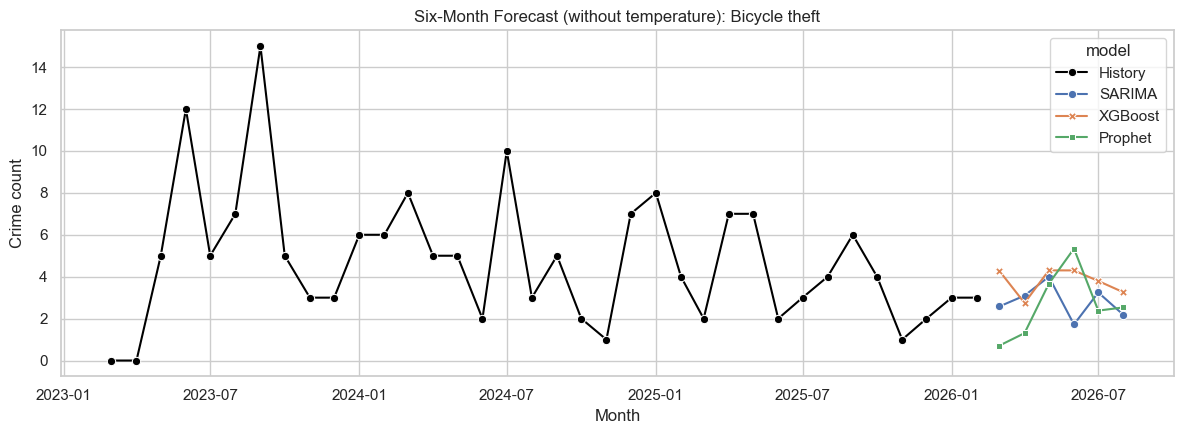

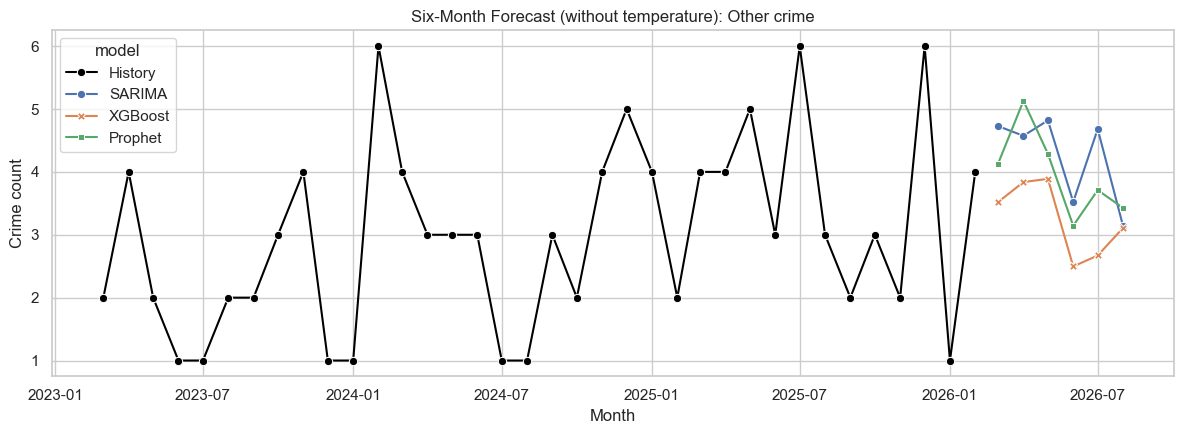

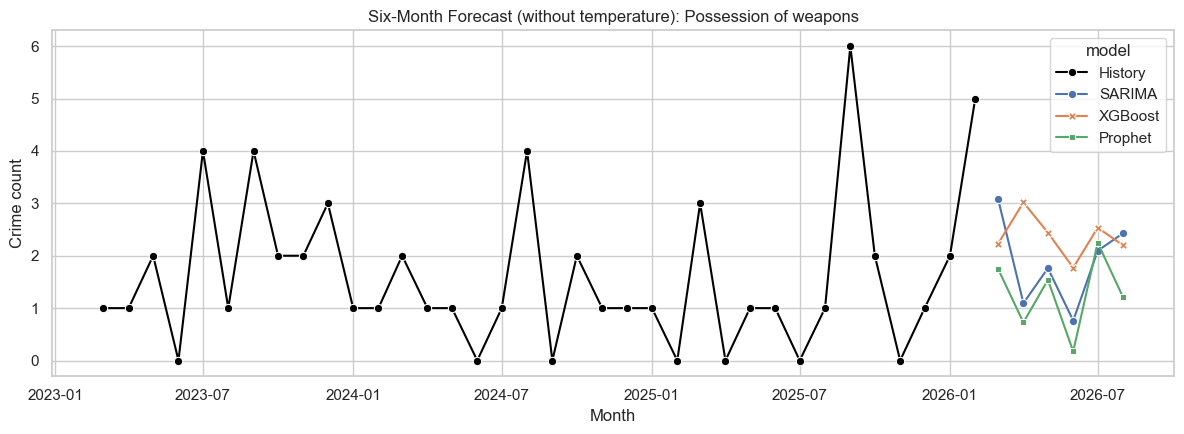

In [16]:
def plot_future_forecast_for_crime_type(crime_type: str) -> None:
    history = target_monthly[target_monthly["Crime type"].eq(crime_type)].sort_values("Month")
    future = future_forecasts_df[
        future_forecasts_df["Crime type"].eq(crime_type)
        & future_forecasts_df["status"].eq("ok")
    ].copy()
    if "temperature_setting" not in future.columns:
        raise ValueError("Rerun the final forecast cell so future_forecasts_df contains without-temperature forecasts.")
    future = future[future["temperature_setting"].eq("without_temperature")]

    plt.figure(figsize=(12, 4.5))
    sns.lineplot(data=history, x="Month", y="crime_count", color="black", marker="o", label="History")
    if not future.empty:
        sns.lineplot(
            data=future,
            x="Month",
            y="predicted",
            hue="model",
            style="model",
            markers=True,
            dashes=False,
        )
    plt.title(f"Six-Month Forecast (without temperature): {crime_type}")
    plt.xlabel("Month")
    plt.ylabel("Crime count")
    plt.tight_layout()
    plt.show()


for crime_type in crime_type_distribution["Crime type"]:
    plot_future_forecast_for_crime_type(crime_type)
